# N01 — Cohorts, Labels and Protected Splits

**Research question.** Which OAI and NHANES III knees are included, how do the cohorts differ, and are the final participant-level splits valid?

**Execution rule.** This notebook reconstructs and validates cohorts only. It does not train a model. The original validated cohort logic is preserved; final outputs are written to the new presentation root.


## Reader Guide

**Pipeline role:** Reconstructs the cohorts and freezes the participant-level protection boundaries used by every later stage.

**Inputs:** Original OAI and NHANES III source records plus the accepted N00 measurement protocol. **Produces:** validated cohort files, shared-concept records, and discovery/confirmation split manifests.

**Reading route:** source continuity -> label reconstruction -> integrity and cohort accounting -> protected split -> descriptive figures and frozen manifests.

## Source continuity

This final notebook preserves the previously executed cohort reconstruction logic so the scientific cohort does not silently change during presentation cleanup. Any change in patient counts, split hashes, or label distributions must stop the pipeline and be investigated.


# 0. Frozen protocol

- N00 must already be accepted.
- OAI and NHANES labels are reconstructed from original source files.
- OAI uses baseline human readings from read project 15.
- NHANES uses the official `xr.dat` fixed-width layout.
- KL remains five-class, grades 0–4.
- Shared primary concepts are maximum osteophyte grade and maximum sclerosis grade.
- NHANES JSN is structurally missing and is never zero-imputed.
- NHANES is split by patient into discovery and protected confirmation subsets.
- Existing frozen split manifests are validated and reused, never silently replaced.
- Prior exploratory access to NHANES is disclosed.
- Shift magnitudes are scientific results, not pass criteria.
- Every required output must exist on Google Drive before N01 can pass.

In [1]:



from pathlib import Path

import sys



IN_COLAB = "google.colab" in sys.modules



if IN_COLAB:

    from google.colab import drive

    drive.mount("/content/drive", force_remount=False)



PROJECT_ROOT = Path("/content/drive/MyDrive/Master Thesis")



if not PROJECT_ROOT.exists():

    raise FileNotFoundError(

        "Google Drive project root is unavailable:\n"

        f"{PROJECT_ROOT}"

    )



THESIS_ROOT = PROJECT_ROOT / "thesis"

RESULTS_ROOT = THESIS_ROOT / "results"

FIGURES_ROOT = THESIS_ROOT / "figures"

TABLES_ROOT = THESIS_ROOT / "tables"

MANIFESTS = THESIS_ROOT / "manifests"

NOTEBOOKS_ROOT = THESIS_ROOT / "notebooks"



STAGE = "N01"

RESULTS = RESULTS_ROOT / STAGE

FIGURES = FIGURES_ROOT / STAGE

TABLES = TABLES_ROOT / STAGE

CHECKS = RESULTS / "checks"

INTERMEDIATE = RESULTS / "intermediate"

FINAL = RESULTS / "final"



for folder in (

    THESIS_ROOT,

    RESULTS_ROOT,

    FIGURES_ROOT,

    TABLES_ROOT,

    MANIFESTS,

    NOTEBOOKS_ROOT,

    RESULTS,

    FIGURES,

    TABLES,

    CHECKS,

    INTERMEDIATE,

    FINAL,

):

    folder.mkdir(parents=True, exist_ok=True)



write_test = THESIS_ROOT / ".n01_write_test"

write_test.write_text("N01", encoding="utf-8")



if not write_test.exists():

    raise RuntimeError("Google Drive is not writable.")



write_test.unlink()



print("PROJECT_ROOT:", PROJECT_ROOT)

print("RESULTS:", RESULTS)

print("FIGURES:", FIGURES)

print("TABLES:", TABLES)

print("MANIFESTS:", MANIFESTS)

print("CHECKS:", CHECKS)

print("INTERMEDIATE:", INTERMEDIATE)

print("FINAL:", FINAL)

print("Drive write preflight: PASS")

Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/Master Thesis
RESULTS: /content/drive/MyDrive/Master Thesis/thesis/results/N01
FIGURES: /content/drive/MyDrive/Master Thesis/thesis/figures/N01
TABLES: /content/drive/MyDrive/Master Thesis/thesis/tables/N01
MANIFESTS: /content/drive/MyDrive/Master Thesis/thesis/manifests
CHECKS: /content/drive/MyDrive/Master Thesis/thesis/results/N01/checks
INTERMEDIATE: /content/drive/MyDrive/Master Thesis/thesis/results/N01/intermediate
FINAL: /content/drive/MyDrive/Master Thesis/thesis/results/N01/final
Drive write preflight: PASS


In [2]:



from __future__ import annotations



import hashlib

import json

import os

import platform

import re

import shutil

import sys

import textwrap

from dataclasses import asdict, dataclass

from datetime import datetime, timezone

from typing import Any



import matplotlib as mpl

import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

import scipy

from scipy.spatial.distance import jensenshannon

from scipy.stats import chi2_contingency, wasserstein_distance

import sklearn

from sklearn.model_selection import StratifiedShuffleSplit



RUN_MODE = os.environ.get("N01_RUN_MODE", "paper").strip().lower()



if RUN_MODE not in {"paper", "smoke"}:

    raise ValueError("N01_RUN_MODE must be 'paper' or 'smoke'.")



@dataclass(frozen=True)

class N01Config:

    split_seed: int = 20260802

    confirmation_fraction: float = 0.50

    bootstrap_replicates_paper: int = 2000

    bootstrap_replicates_smoke: int = 100

    alpha: float = 0.05

    rare_source_count: int = 5

    minimum_nonmissing_per_cohort: int = 20

    maximum_plotted_states: int = 24



CONFIG = N01Config()



BOOTSTRAP_REPLICATES = (

    CONFIG.bootstrap_replicates_paper

    if RUN_MODE == "paper"

    else CONFIG.bootstrap_replicates_smoke

)



SHARED_CONCEPTS = ("osteophyte_max", "sclerosis_max")

OAI_ONLY_CONCEPTS = ("jsn_max",)

CONCEPT_LEVELS = {

    "osteophyte_max": (0, 1, 2, 3),

    "sclerosis_max": (0, 1, 2, 3),

    "jsn_max": (0, 1, 2, 3),

}

KL_LEVELS = (0, 1, 2, 3, 4)



N00_STATUS = (

    THESIS_ROOT

    / "results"

    / "N00"

    / "n00_validation_status.json"

)



if not N00_STATUS.exists():

    raise FileNotFoundError(

        f"Accepted N00 status is missing:\n{N00_STATUS}"

    )



n00_status = json.loads(

    N00_STATUS.read_text(encoding="utf-8")

)



if n00_status.get("accepted") is not True:

    raise RuntimeError("N00 has not been accepted. N01 cannot continue.")



def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:

    digest = hashlib.sha256()

    with path.open("rb") as handle:

        for block in iter(lambda: handle.read(chunk_size), b""):

            digest.update(block)

    return digest.hexdigest()



def atomic_csv(frame: pd.DataFrame, path: Path) -> None:

    path.parent.mkdir(parents=True, exist_ok=True)

    temporary = path.with_suffix(path.suffix + ".tmp")

    frame.to_csv(temporary, index=False)

    temporary.replace(path)



def atomic_json(payload: dict[str, Any], path: Path) -> None:

    path.parent.mkdir(parents=True, exist_ok=True)

    temporary = path.with_suffix(path.suffix + ".tmp")

    temporary.write_text(

        json.dumps(payload, indent=2),

        encoding="utf-8",

    )

    temporary.replace(path)



ENVIRONMENT = {

    "stage": STAGE,

    "run_mode": RUN_MODE,

    "executed_utc": datetime.now(timezone.utc).isoformat(),

    "project_root": str(PROJECT_ROOT),

    "python": sys.version,

    "platform": platform.platform(),

    "numpy": np.__version__,

    "pandas": pd.__version__,

    "scipy": scipy.__version__,

    "scikit_learn": sklearn.__version__,

    "matplotlib": mpl.__version__,

    "config": asdict(CONFIG),

    "n00_status_sha256": sha256_file(N00_STATUS),

}



atomic_json(ENVIRONMENT, RESULTS / "environment.json")

display(pd.Series(ENVIRONMENT, name="value").to_frame())

,value
stage,N01
run_mode,paper
executed_utc,2026-08-05T07:46:57.189770+00:00
project_root,/content/drive/MyDrive/Master Thesis
python,"3.12.13 (main, Mar 4 2026, 09:23:07) [GCC 11...."
platform,Linux-6.6.122+-x86_64-with-glibc2.35
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
scikit_learn,1.6.1


# 1. Original source files

N01 uses explicit original inputs.

## OAI

- `oai/assessments/XR Knee Semi-Quant/KXR_SQ_BU00.txt`
- `oai/oai_processed_labels.csv`
- `oai/processed/`

## NHANES III

- `nhanes3/labels_all.csv`
- `nhanes3/processed/`
- `xr.dat`, accepted at either:
  - `nhanes3/xr.dat`; or
  - `discovery_pipeline/raw_cache/xr.dat`.

The archived D01-derived CSV files are not inputs.

In [3]:



OAI_ASSESSMENT = (

    PROJECT_ROOT

    / "oai"

    / "assessments"

    / "XR Knee Semi-Quant"

    / "KXR_SQ_BU00.txt"

)

OAI_IMAGE_INDEX = (

    PROJECT_ROOT

    / "oai"

    / "oai_processed_labels.csv"

)

OAI_IMAGE_DIR = (

    PROJECT_ROOT

    / "oai"

    / "processed"

)



NHANES_LABEL_INDEX = (

    PROJECT_ROOT

    / "nhanes3"

    / "labels_all.csv"

)

NHANES_IMAGE_DIR = (

    PROJECT_ROOT

    / "nhanes3"

    / "processed"

)



NHANES_XR_CANDIDATES = [

    PROJECT_ROOT / "nhanes3" / "xr.dat",

    PROJECT_ROOT / "discovery_pipeline" / "raw_cache" / "xr.dat",

]



existing_xr = [

    path.resolve()

    for path in NHANES_XR_CANDIDATES

    if path.exists() and path.is_file()

]



if len(existing_xr) == 0:

    raise FileNotFoundError(

        "NHANES III xr.dat was not found. Expected one of:\n"

        + "\n".join(f"  - {path}" for path in NHANES_XR_CANDIDATES)

    )



if len(existing_xr) > 1:

    hashes = {sha256_file(path) for path in existing_xr}

    if len(hashes) != 1:

        raise RuntimeError(

            "Multiple non-identical xr.dat files were found:\n"

            + "\n".join(f"  - {path}" for path in existing_xr)

        )



NHANES_XR = existing_xr[0]



required_sources = [

    OAI_ASSESSMENT,

    OAI_IMAGE_INDEX,

    OAI_IMAGE_DIR,

    NHANES_LABEL_INDEX,

    NHANES_IMAGE_DIR,

    NHANES_XR,

]



missing_sources = [

    path for path in required_sources

    if not path.exists()

]



if missing_sources:

    raise FileNotFoundError(

        "Required source paths are missing:\n"

        + "\n".join(f"  - {path}" for path in missing_sources)

    )



FORBIDDEN_INPUT_NAMES = {

    "t01_oai.csv",

    "t01_nhanes.csv",

    "oai_human_feature_labels.csv",

    "nhanes_human_feature_labels.csv",

}



source_registry = []



for name, path in {

    "oai_assessment": OAI_ASSESSMENT,

    "oai_image_index": OAI_IMAGE_INDEX,

    "oai_image_directory": OAI_IMAGE_DIR,

    "nhanes_label_index": NHANES_LABEL_INDEX,

    "nhanes_image_directory": NHANES_IMAGE_DIR,

    "nhanes_xr": NHANES_XR,

}.items():

    source_registry.append({

        "resource": name,

        "path": str(path),

        "kind": "directory" if path.is_dir() else "file",

        "exists": path.exists(),

        "size_bytes": path.stat().st_size if path.is_file() else None,

        "sha256": sha256_file(path) if path.is_file() else None,

        "modified_utc": datetime.fromtimestamp(path.stat().st_mtime, tz=timezone.utc).isoformat() if path.exists() else None,

        "forbidden_derived_input": path.name in FORBIDDEN_INPUT_NAMES,

    })



source_registry = pd.DataFrame(source_registry)



if source_registry["forbidden_derived_input"].any():

    raise RuntimeError("A forbidden derived input entered N01.")



atomic_csv(

    source_registry,

    RESULTS / "n01_source_registry.csv",

)

display(source_registry)

,resource,path,kind,exists,size_bytes,sha256,modified_utc,forbidden_derived_input
0,oai_assessment,/content/drive/MyDrive/Master Thesis/oai/asses...,file,True,7007451.0,4afc5c38e2c68739e6a22eb8f498f58acff3c301d46a09...,2026-04-26T15:15:30+00:00,False
1,oai_image_index,/content/drive/MyDrive/Master Thesis/oai/oai_p...,file,True,440636.0,ed22c7e11e903b553dfe15a18fa495d2184506bf076915...,2026-05-28T09:29:45+00:00,False
2,oai_image_directory,/content/drive/MyDrive/Master Thesis/oai/proce...,directory,True,NaN,None,2026-05-28T07:15:40+00:00,False
3,nhanes_label_index,/content/drive/MyDrive/Master Thesis/nhanes3/l...,file,True,301861.0,a4c112e8dea5f1d46de803d2fbcf7afeb0869e05674347...,2026-04-26T14:46:27+00:00,False
4,nhanes_image_directory,/content/drive/MyDrive/Master Thesis/nhanes3/p...,directory,True,NaN,None,2026-04-19T21:00:45+00:00,False
5,nhanes_xr,/content/drive/MyDrive/Master Thesis/discovery...,file,True,75079.0,d1725dc94640145f9385c2efb710bcc30fdedc505546fd...,2026-07-24T07:35:28+00:00,False


# 2. Parsing and validation helpers

The helpers below normalize participant IDs and knee side, validate clinical grades, detect OAI variable families, and create reproducible file manifests.

In [4]:



def normalize_id(value: Any) -> Any:

    if pd.isna(value):

        return pd.NA

    text = str(value).strip()

    if re.fullmatch(r"[+-]?\d+\.0+", text):

        text = text.split(".", 1)[0]

    return text if text else pd.NA





def normalize_side(value: Any) -> Any:

    if pd.isna(value):

        return pd.NA

    text = str(value).strip().upper()

    mapping = {

        "R": "R", "RIGHT": "R", "RT": "R", "1": "R", "1.0": "R",

        "L": "L", "LEFT": "L", "LT": "L", "2": "L", "2.0": "L",

    }

    return mapping.get(text, pd.NA)





def parse_colon_code(value: Any) -> float:

    if pd.isna(value):

        return np.nan

    try:

        return float(int(str(value).split(":", 1)[0].strip()))

    except Exception:

        return np.nan





def valid_feature(series: pd.Series) -> pd.Series:

    values = pd.to_numeric(series, errors="coerce")

    return values.where(values.between(0, 3))





def validate_levels(frame: pd.DataFrame, column: str, allowed: tuple[int, ...], dataset: str) -> None:

    values = pd.to_numeric(frame[column], errors="coerce").dropna()

    invalid = sorted(set(values.unique()) - set(allowed))

    if invalid:

        raise ValueError(

            f"{dataset}.{column} has invalid values: {invalid}. "

            f"Allowed values are {allowed}."

        )





def require_columns(frame: pd.DataFrame, required: set[str], label: str) -> None:

    missing = sorted(required - set(frame.columns))

    if missing:

        raise KeyError(f"{label} is missing required columns: {missing}")





def assert_unique(frame: pd.DataFrame, columns: list[str], label: str) -> None:

    duplicated = frame.duplicated(columns, keep=False)

    if duplicated.any():

        display(frame.loc[duplicated, columns].head(30))

        raise RuntimeError(f"{label} contains duplicate keys: {columns}")





def image_exists(directory: Path, filename: str) -> bool:

    return (directory / str(filename)).is_file()





def standardized_mean_difference(source: pd.Series, target: pd.Series) -> float:

    source_values = pd.to_numeric(source, errors="coerce").dropna().astype(float)

    target_values = pd.to_numeric(target, errors="coerce").dropna().astype(float)

    pooled_variance = (source_values.var(ddof=1) + target_values.var(ddof=1)) / 2

    if not np.isfinite(pooled_variance) or pooled_variance <= 0:

        return np.nan

    return float((target_values.mean() - source_values.mean()) / np.sqrt(pooled_variance))





def five_number_summary(series: pd.Series) -> dict[str, float]:

    values = pd.to_numeric(series, errors="coerce").dropna().astype(float)

    if values.empty:

        return {"mean": np.nan, "median": np.nan, "q1": np.nan, "q3": np.nan, "minimum": np.nan, "maximum": np.nan}

    return {

        "mean": float(values.mean()),

        "median": float(values.median()),

        "q1": float(values.quantile(0.25)),

        "q3": float(values.quantile(0.75)),

        "minimum": float(values.min()),

        "maximum": float(values.max()),

    }





def write_figure_metadata(records: list[dict[str, Any]]) -> None:

    atomic_json({"stage": STAGE, "figures": records}, RESULTS / "figure_metadata.json")





assert normalize_side("1") == "R"

assert normalize_side("2") == "L"

assert parse_colon_code("3: severe") == 3

assert np.isclose(standardized_mean_difference(pd.Series([0, 1, 2]), pd.Series([1, 2, 3])), 1.0)

print("Parsing and validation helper tests: PASS")

Parsing and validation helper tests: PASS


# 3. Reconstruct OAI human readings

The OAI baseline semi-quantitative table is parsed directly.

N01:

- keeps read project 15;
- identifies KL, osteophyte, JSN, and sclerosis variable families;
- parses all detected site scores;
- derives maximum and sum scores;
- resolves duplicate patient-side readings using the median;
- merges the reconstructed readings to the processed image index.

In [5]:



def detect_oai_family(column: str) -> str:

    suffix = column.upper().replace("V00XR", "")

    if suffix.startswith("KL"):

        return "kl"

    if suffix.startswith("OS"):

        return "osteophyte"

    if suffix.startswith("JS") or "JSN" in suffix:

        return "jsn"

    if suffix.startswith("SC") or "SCL" in suffix:

        return "sclerosis"

    return "other"





def detect_oai_variable_groups(frame: pd.DataFrame) -> dict[str, list[str]]:

    groups: dict[str, list[str]] = {}

    for column in frame.columns:

        if str(column).upper().startswith("V00XR"):

            groups.setdefault(detect_oai_family(str(column)), []).append(str(column))

    for family in ("kl", "osteophyte", "jsn", "sclerosis"):

        if not groups.get(family):

            raise KeyError(f"OAI family was not detected: {family}. Detected: {sorted(groups)}")

    if len(groups["kl"]) != 1:

        raise RuntimeError(f"Expected one baseline KL field, found: {groups['kl']}")

    return groups





def aggregate_site_features(frame: pd.DataFrame, family: str, source_columns: list[str]) -> tuple[pd.DataFrame, list[str]]:

    parsed_columns: list[str] = []

    for index, source_column in enumerate(source_columns, start=1):

        output_column = f"{family}_site_{index}"

        frame[output_column] = valid_feature(frame[source_column].map(parse_colon_code))

        parsed_columns.append(output_column)

    frame[f"{family}_max"] = frame[parsed_columns].max(axis=1, skipna=True)

    frame[f"{family}_sum"] = frame[parsed_columns].sum(axis=1, min_count=1)

    return frame, parsed_columns





def parse_oai_assessment(path: Path, read_project: int = 15) -> tuple[pd.DataFrame, pd.DataFrame, int]:

    raw = pd.read_csv(path, sep="|", dtype=str, low_memory=False)

    require_columns(raw, {"ID", "SIDE", "READPRJ"}, "OAI assessment")

    groups = detect_oai_variable_groups(raw)

    work = raw.copy()

    work["patient_id"] = work["ID"].map(normalize_id)

    work["side"] = work["SIDE"].astype(str).str.extract(r"^(\d+):")[0].map({"1": "R", "2": "L"})

    work["read_project"] = pd.to_numeric(work["READPRJ"], errors="coerce")

    work = work.loc[work["read_project"].eq(read_project)].copy()

    work["kl_grade"] = work[groups["kl"][0]].map(parse_colon_code)



    component_map: dict[str, list[str]] = {}

    for family in ("osteophyte", "jsn", "sclerosis"):

        work, component_map[family] = aggregate_site_features(work, family, groups[family])



    keep = ["patient_id", "side", "kl_grade"] + [

        column for columns in component_map.values() for column in columns

    ] + [

        "osteophyte_max", "osteophyte_sum", "jsn_max", "jsn_sum",

        "sclerosis_max", "sclerosis_sum",

    ]

    parsed = work[keep].copy()

    parsed = parsed.loc[

        parsed["patient_id"].notna()

        & parsed["side"].isin(["L", "R"])

        & parsed["kl_grade"].between(0, 4)

    ].copy()

    for column in keep[2:]:

        parsed[column] = pd.to_numeric(parsed[column], errors="coerce")



    duplicate_rows = int(parsed.duplicated(["patient_id", "side"], keep=False).sum())

    if duplicate_rows:

        numeric_columns = [column for column in parsed.columns if column not in {"patient_id", "side"}]

        parsed = parsed.groupby(["patient_id", "side"], as_index=False)[numeric_columns].median()



    parsed["dataset"] = "OAI"

    parsed["patient_key"] = "OAI::" + parsed["patient_id"].astype(str)

    parsed["knee_key"] = parsed["patient_key"] + "::" + parsed["side"]

    assert_unique(parsed, ["knee_key"], "OAI reconstructed readings")



    schema = pd.DataFrame([

        {

            "family": family,

            "source_columns": " | ".join(groups[family]),

            "parsed_columns": " | ".join(component_map.get(family, [])),

            "number_of_sites": len(component_map.get(family, [])),

        }

        for family in ("kl", "osteophyte", "jsn", "sclerosis")

    ])

    return parsed, schema, duplicate_rows





oai_human_all, oai_feature_schema, oai_duplicate_rows_before = parse_oai_assessment(OAI_ASSESSMENT)

atomic_csv(oai_feature_schema, RESULTS / "n01_oai_feature_schema.csv")

atomic_csv(oai_human_all, INTERMEDIATE / "oai_human_features_reconstructed.csv")



print("OAI reconstructed knees:", len(oai_human_all))

print("OAI reconstructed patients:", oai_human_all["patient_id"].nunique())

print("Duplicate rows before resolution:", oai_duplicate_rows_before)

display(oai_feature_schema)

display(oai_human_all[["kl_grade", "osteophyte_max", "osteophyte_sum", "jsn_max", "sclerosis_max"]].describe())

OAI reconstructed knees: 8921
OAI reconstructed patients: 4490
Duplicate rows before resolution: 0


,family,source_columns,parsed_columns,number_of_sites
0,kl,V00XRKL,,0
1,osteophyte,V00XROSFM | V00XROSTM | V00XROSFL | V00XROSTL,osteophyte_site_1 | osteophyte_site_2 | osteop...,4
2,jsn,V00XRJSM | V00XRJSL,jsn_site_1 | jsn_site_2,2
3,sclerosis,V00XRSCFM | V00XRSCTM | V00XRSCFL | V00XRSCTL,sclerosis_site_1 | sclerosis_site_2 | sclerosi...,4


,kl_grade,osteophyte_max,osteophyte_sum,jsn_max,sclerosis_max
count,8921.000000,5507.000000,5507.000000,8921.000000,5506.000000
mean,1.255353,1.323770,2.809878,0.627844,0.675263
std,1.198575,1.002333,2.787287,0.841766,0.870275
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,1.000000,0.000000,0.000000
50%,1.000000,1.000000,2.000000,0.000000,0.000000
75%,2.000000,2.000000,4.000000,1.000000,1.000000
max,4.000000,3.000000,12.000000,3.000000,3.000000


In [6]:



def link_oai_images(index_path: Path, image_directory: Path, human: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:

    raw = pd.read_csv(index_path, low_memory=False)

    require_columns(raw, {"filename", "subject_id", "side", "kl_grade"}, "OAI image index")

    index = pd.DataFrame({

        "filename": raw["filename"].astype(str),

        "patient_id": raw["subject_id"].map(normalize_id),

        "side": raw["side"].map(normalize_side),

        "index_kl_grade": pd.to_numeric(raw["kl_grade"], errors="coerce"),

        "existing_split": raw["split"].astype("string") if "split" in raw.columns else pd.NA,

    })

    assert_unique(index, ["patient_id", "side"], "OAI image index")

    assert_unique(index, ["filename"], "OAI image index filenames")



    linked = index.merge(human, on=["patient_id", "side"], how="left", validate="one_to_one", indicator="human_merge")

    linked["image_exists"] = linked["filename"].map(lambda value: image_exists(image_directory, value))

    linked["kl_agreement"] = np.isclose(linked["index_kl_grade"], linked["kl_grade"], equal_nan=False)

    linked["dataset"] = "OAI"

    linked["patient_key"] = "OAI::" + linked["patient_id"].astype(str)

    linked["knee_key"] = linked["patient_key"] + "::" + linked["side"]

    linked["exclusion_reason"] = np.select(

        [linked["human_merge"].ne("both"), ~linked["kl_agreement"], ~linked["image_exists"], linked["osteophyte_max"].isna(), linked["sclerosis_max"].isna()],

        ["No matching human assessment", "KL disagreement between source files", "Processed image missing", "Osteophyte grade missing", "Sclerosis grade missing"],

        default="Included",

    )

    included = linked.loc[linked["exclusion_reason"].eq("Included")].copy()

    assert_unique(included, ["knee_key"], "Included OAI cohort")

    return linked, included





OAI, OAI_INCLUDED = link_oai_images(OAI_IMAGE_INDEX, OAI_IMAGE_DIR, oai_human_all)

atomic_csv(OAI, RESULTS / "n01_oai_all_linked.csv")

atomic_csv(OAI_INCLUDED, RESULTS / "n01_oai_cohort.csv")

atomic_csv(OAI_INCLUDED, FINAL / "oai_cohort_frozen.csv")



print("OAI indexed knees:", len(OAI))

print("OAI included knees:", len(OAI_INCLUDED))

print("OAI included patients:", OAI_INCLUDED["patient_id"].nunique())

display(OAI["exclusion_reason"].value_counts(dropna=False).rename_axis("reason").reset_index(name="knees"))

OAI indexed knees: 8547
OAI included knees: 5252
OAI included patients: 2647


,reason,knees
0,Included,5252
1,Osteophyte grade missing,3294
2,Sclerosis grade missing,1


# 4. Reconstruct NHANES III human readings

The official fixed-width layout is:

- participant identifier in positions 1–5;
- right and left KL grades;
- four osteophyte sites per knee;
- four sclerosis sites per knee;
- additional fields not used in the primary shared-concept analysis.

N01 derives maximum and sum scores for each concept and explicitly creates missing JSN fields.

In [7]:



NHANES_FIELD_NAMES = [

    "SEQN", "XRPKLR", "XRPKLL",

    "XRPOMFR", "XRPOMFL", "XRPOMTR", "XRPOMTL", "XRPOLFR", "XRPOLFL", "XRPOLTR", "XRPOLTL",

    "XRPSMFR", "XRPSMFL", "XRPSMTR", "XRPSMTL", "XRPSLFR", "XRPSLFL", "XRPSLTR", "XRPSLTL",

    "XRPCHOR", "XRPCHOL", "XRPJRR", "XRPJRL",

]

NHANES_FIELD_WIDTHS = [5] + [1] * 22





def parse_nhanes_xr(path: Path) -> tuple[pd.DataFrame, pd.DataFrame, int]:

    wide = pd.read_fwf(path, widths=NHANES_FIELD_WIDTHS, names=NHANES_FIELD_NAMES, dtype=str, header=None)

    require_columns(wide, set(NHANES_FIELD_NAMES), "NHANES xr.dat")

    wide["SEQN"] = wide["SEQN"].map(normalize_id)

    rows: list[pd.DataFrame] = []



    for side in ("R", "L"):

        osteophyte_sources = [f"XRPOMF{side}", f"XRPOMT{side}", f"XRPOLF{side}", f"XRPOLT{side}"]

        sclerosis_sources = [f"XRPSMF{side}", f"XRPSMT{side}", f"XRPSLF{side}", f"XRPSLT{side}"]

        side_frame = pd.DataFrame({

            "patient_id": wide["SEQN"],

            "side": side,

            "kl_grade": pd.to_numeric(wide[f"XRPKL{side}"], errors="coerce"),

        })

        for index, source_column in enumerate(osteophyte_sources, start=1):

            side_frame[f"osteophyte_site_{index}"] = valid_feature(wide[source_column])

        for index, source_column in enumerate(sclerosis_sources, start=1):

            side_frame[f"sclerosis_site_{index}"] = valid_feature(wide[source_column])

        osteophyte_sites = [f"osteophyte_site_{index}" for index in range(1, 5)]

        sclerosis_sites = [f"sclerosis_site_{index}" for index in range(1, 5)]

        side_frame["osteophyte_max"] = side_frame[osteophyte_sites].max(axis=1, skipna=True)

        side_frame["osteophyte_sum"] = side_frame[osteophyte_sites].sum(axis=1, min_count=1)

        side_frame["sclerosis_max"] = side_frame[sclerosis_sites].max(axis=1, skipna=True)

        side_frame["sclerosis_sum"] = side_frame[sclerosis_sites].sum(axis=1, min_count=1)

        side_frame["jsn_max"] = np.nan

        side_frame["jsn_sum"] = np.nan

        rows.append(side_frame)



    parsed = pd.concat(rows, ignore_index=True)

    parsed = parsed.loc[parsed["patient_id"].notna() & parsed["kl_grade"].between(0, 4)].copy()

    duplicate_rows = int(parsed.duplicated(["patient_id", "side"], keep=False).sum())

    parsed = parsed.drop_duplicates(["patient_id", "side"]).copy()

    parsed["dataset"] = "NHANES"

    parsed["patient_key"] = "NHANES::" + parsed["patient_id"].astype(str)

    parsed["knee_key"] = parsed["patient_key"] + "::" + parsed["side"]

    assert_unique(parsed, ["knee_key"], "NHANES reconstructed readings")



    layout = pd.DataFrame({

        "field": NHANES_FIELD_NAMES,

        "width": NHANES_FIELD_WIDTHS,

        "position_start_1_indexed": np.cumsum([1] + NHANES_FIELD_WIDTHS[:-1]),

    })

    layout["position_end_1_indexed"] = layout["position_start_1_indexed"] + layout["width"] - 1

    return parsed, layout, duplicate_rows





nhanes_human_all, nhanes_layout, nhanes_duplicate_rows_before = parse_nhanes_xr(NHANES_XR)

atomic_csv(nhanes_layout, RESULTS / "n01_nhanes_fixed_width_layout.csv")

atomic_csv(nhanes_human_all, INTERMEDIATE / "nhanes_human_features_reconstructed.csv")



print("NHANES reconstructed knees:", len(nhanes_human_all))

print("NHANES reconstructed patients:", nhanes_human_all["patient_id"].nunique())

print("Duplicate rows before resolution:", nhanes_duplicate_rows_before)

display(nhanes_layout)

display(nhanes_human_all[["kl_grade", "osteophyte_max", "osteophyte_sum", "sclerosis_max"]].describe())

NHANES reconstructed knees: 4791
NHANES reconstructed patients: 2415
Duplicate rows before resolution: 0


,field,width,position_start_1_indexed,position_end_1_indexed
0,SEQN,5,1,5
1,XRPKLR,1,6,6
2,XRPKLL,1,7,7
3,XRPOMFR,1,8,8
4,XRPOMFL,1,9,9
5,XRPOMTR,1,10,10
6,XRPOMTL,1,11,11
7,XRPOLFR,1,12,12
8,XRPOLFL,1,13,13
9,XRPOLTR,1,14,14


,kl_grade,osteophyte_max,osteophyte_sum,sclerosis_max
count,4791.000000,4791.000000,4791.000000,4787.000000
mean,0.920267,0.457525,0.921728,0.262377
std,1.112234,0.710656,1.691169,0.513596
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,2.000000,1.000000,1.000000,0.000000
max,4.000000,3.000000,11.000000,3.000000


In [8]:



def link_nhanes_images(index_path: Path, image_directory: Path, human: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:

    raw = pd.read_csv(index_path, low_memory=False)

    require_columns(raw, {"filename", "seqn", "side", "kl_grade"}, "NHANES image index")

    index = pd.DataFrame({

        "filename": raw["filename"].astype(str),

        "patient_id": raw["seqn"].map(normalize_id),

        "side": raw["side"].map(normalize_side),

        "index_kl_grade": pd.to_numeric(raw["kl_grade"], errors="coerce"),

    })

    assert_unique(index, ["patient_id", "side"], "NHANES image index")

    assert_unique(index, ["filename"], "NHANES image index filenames")



    linked = index.merge(human, on=["patient_id", "side"], how="left", validate="one_to_one", indicator="human_merge")

    linked["image_exists"] = linked["filename"].map(lambda value: image_exists(image_directory, value))

    linked["kl_agreement"] = np.isclose(linked["index_kl_grade"], linked["kl_grade"], equal_nan=False)

    linked["dataset"] = "NHANES"

    linked["patient_key"] = "NHANES::" + linked["patient_id"].astype(str)

    linked["knee_key"] = linked["patient_key"] + "::" + linked["side"]

    linked["exclusion_reason"] = np.select(

        [linked["human_merge"].ne("both"), ~linked["kl_agreement"], ~linked["image_exists"], linked["osteophyte_max"].isna(), linked["sclerosis_max"].isna()],

        ["No matching human assessment", "KL disagreement between source files", "Processed image missing", "Osteophyte grade missing", "Sclerosis grade missing"],

        default="Included",

    )

    included = linked.loc[linked["exclusion_reason"].eq("Included")].copy()

    assert_unique(included, ["knee_key"], "Included NHANES cohort")

    if included["jsn_max"].notna().any():

        raise RuntimeError("NHANES JSN must remain structurally missing.")

    return linked, included





NHANES, NHANES_INCLUDED = link_nhanes_images(NHANES_LABEL_INDEX, NHANES_IMAGE_DIR, nhanes_human_all)

atomic_csv(NHANES, RESULTS / "n01_nhanes_all_linked.csv")

atomic_csv(NHANES_INCLUDED, RESULTS / "n01_nhanes_cohort.csv")

atomic_csv(NHANES_INCLUDED, FINAL / "nhanes_cohort_frozen.csv")



print("NHANES indexed knees:", len(NHANES))

print("NHANES included knees:", len(NHANES_INCLUDED))

print("NHANES included patients:", NHANES_INCLUDED["patient_id"].nunique())

display(NHANES["exclusion_reason"].value_counts(dropna=False).rename_axis("reason").reset_index(name="knees"))

NHANES indexed knees: 4791
NHANES included knees: 4781
NHANES included patients: 2410


,reason,knees
0,Included,4781
1,Processed image missing,6
2,Sclerosis grade missing,4


# 5. Clinical validity and cohort accounting

N01 now verifies:

- unique patient-side keys;
- five-class KL ranges;
- valid 0–3 concept grades;
- NHANES JSN absence;
- exact KL agreement between raw human readings and image-label indexes;
- image availability;
- complete exclusion accounting.

In [9]:



for dataset, frame in {

    "OAI": OAI_INCLUDED,

    "NHANES": NHANES_INCLUDED,

}.items():

    if not frame["knee_key"].is_unique:

        raise RuntimeError(

            f"{dataset} included knee keys are not unique."

        )



    validate_levels(

        frame,

        "kl_grade",

        KL_LEVELS,

        dataset,

    )



    for concept in SHARED_CONCEPTS:

        validate_levels(

            frame,

            concept,

            CONCEPT_LEVELS[concept],

            dataset,

        )



validate_levels(

    OAI_INCLUDED,

    "jsn_max",

    CONCEPT_LEVELS["jsn_max"],

    "OAI",

)



if NHANES_INCLUDED["jsn_max"].notna().any():

    raise RuntimeError(

        "NHANES JSN contains nonmissing values."

    )



flow_rows = []



for dataset, frame in {

    "OAI": OAI,

    "NHANES": NHANES,

}.items():

    total = len(frame)



    for reason, count in (

        frame["exclusion_reason"]

        .value_counts(dropna=False)

        .items()

    ):

        flow_rows.append({

            "dataset": dataset,

            "stage": reason,

            "knees": int(count),

            "percent_of_index": 100 * count / total,

        })



exclusion_flow = pd.DataFrame(flow_rows)

atomic_csv(

    exclusion_flow,

    RESULTS / "n01_exclusion_flow.csv",

)



cohort_accounting = pd.DataFrame([

    {

        "dataset": dataset,

        "indexed_knees": len(full),

        "included_knees": len(included),

        "included_patients": included["patient_id"].nunique(),

        "bilateral_patients": int(

            included.groupby("patient_id")["side"]

            .nunique()

            .eq(2)

            .sum()

        ),

        "unilateral_patients": int(

            included.groupby("patient_id")["side"]

            .nunique()

            .eq(1)

            .sum()

        ),

        "image_available_percent": 100 * full["image_exists"].mean(),

        "kl_agreement_percent": 100 * full["kl_agreement"].mean(),

        "included_percent": 100 * len(included) / len(full),

    }

    for dataset, full, included in (

        ("OAI", OAI, OAI_INCLUDED),

        ("NHANES", NHANES, NHANES_INCLUDED),

    )

])



atomic_csv(

    cohort_accounting,

    TABLES / "N01_T01_cohort_accounting.csv",

)



display(cohort_accounting.round(2))

display(exclusion_flow.round(2))

,dataset,indexed_knees,included_knees,included_patients,bilateral_patients,unilateral_patients,image_available_percent,kl_agreement_percent,included_percent
0,OAI,8547,5252,2647,2605,42,100.00,100.0,61.45
1,NHANES,4791,4781,2410,2371,39,99.87,100.0,99.79


,dataset,stage,knees,percent_of_index
0,OAI,Included,5252,61.45
1,OAI,Osteophyte grade missing,3294,38.54
2,OAI,Sclerosis grade missing,1,0.01
3,NHANES,Included,4781,99.79
4,NHANES,Processed image missing,6,0.13
5,NHANES,Sclerosis grade missing,4,0.08


# 5.1. Extended integrity checks

These assertions test structural assumptions that could silently invalidate later analyses.

In [10]:



sanity_rows: list[dict[str, Any]] = []



def record_check(name: str, passed: bool, detail: str) -> None:

    sanity_rows.append({"check": name, "passed": bool(passed), "detail": detail})

    if not passed:

        raise AssertionError(f"Integrity check failed: {name}. {detail}")



for dataset, full, included in (

    ("OAI", OAI, OAI_INCLUDED),

    ("NHANES", NHANES, NHANES_INCLUDED),

):

    knee_counts = included.groupby("patient_id")["side"].nunique()

    record_check(f"{dataset}: each patient has one or two knees", bool(knee_counts.between(1, 2).all()), f"range={knee_counts.min()}–{knee_counts.max()}")

    record_check(f"{dataset}: no duplicate filenames", bool(full["filename"].is_unique), f"duplicate rows={int(full["filename"].duplicated(keep=False).sum())}")

    record_check(f"{dataset}: no duplicate knee keys", bool(included["knee_key"].is_unique), f"knees={len(included)}")

    record_check(f"{dataset}: only L/R side codes", bool(included["side"].isin(["L", "R"]).all()), str(included["side"].value_counts().to_dict()))

    record_check(f"{dataset}: every included image exists", bool(included["image_exists"].all()), f"missing={int((~included['image_exists']).sum())}")

    record_check(f"{dataset}: raw/index KL agreement", bool(included["kl_agreement"].all()), f"disagreement={int((~included['kl_agreement']).sum())}")

    record_check(f"{dataset}: all KL grades represented", set(KL_LEVELS).issubset(set(included["kl_grade"].dropna().astype(int).unique())), str(sorted(included["kl_grade"].dropna().unique())))

    record_check(f"{dataset}: left/right ratio plausible", 0.80 <= (included["side"].eq("R").sum() / max(included["side"].eq("L").sum(), 1)) <= 1.25, str(included["side"].value_counts().to_dict()))

    for concept in SHARED_CONCEPTS:

        record_check(f"{dataset}: {concept} has usable variation", included[concept].nunique(dropna=True) >= 2, f"unique={included[concept].nunique(dropna=True)}")

        record_check(f"{dataset}: {concept} within 0–3", bool(included[concept].dropna().between(0, 3).all()), f"range={included[concept].min()}–{included[concept].max()}")



record_check("OAI JSN is observed", bool(OAI_INCLUDED["jsn_max"].notna().all()), f"missing={int(OAI_INCLUDED['jsn_max'].isna().sum())}")

record_check("NHANES JSN is structurally absent", bool(NHANES_INCLUDED["jsn_max"].isna().all()), f"nonmissing={int(NHANES_INCLUDED['jsn_max'].notna().sum())}")

record_check("OAI and NHANES patient namespaces do not overlap", set(OAI_INCLUDED["patient_key"]).isdisjoint(set(NHANES_INCLUDED["patient_key"])), "dataset-prefixed patient keys")



sanity_checks = pd.DataFrame(sanity_rows)

atomic_csv(sanity_checks, CHECKS / "n01_integrity_checks.csv")

display(sanity_checks)

print(f"Extended integrity checks passed: {sanity_checks['passed'].sum()}/{len(sanity_checks)}")

,check,passed,detail
0,OAI: each patient has one or two knees,True,range=1–2
1,OAI: no duplicate filenames,True,duplicate rows=0
2,OAI: no duplicate knee keys,True,knees=5252
3,OAI: only L/R side codes,True,"{'L': 2631, 'R': 2621}"
4,OAI: every included image exists,True,missing=0
5,OAI: raw/index KL agreement,True,disagreement=0
6,OAI: all KL grades represented,True,"[np.float64(0.0), np.float64(1.0), np.float64(..."
7,OAI: left/right ratio plausible,True,"{'L': 2631, 'R': 2621}"
8,OAI: osteophyte_max has usable variation,True,unique=4
9,OAI: osteophyte_max within 0–3,True,range=0.0–3.0


Extended integrity checks passed: 27/27


# 5.2. Publication-ready descriptive statistics

This table reports sample size, missingness, mean, median, IQR, and range for each clinical variable.

In [11]:



descriptive_rows: list[dict[str, Any]] = []

for dataset, frame in {"OAI": OAI_INCLUDED, "NHANES": NHANES_INCLUDED}.items():

    for variable in ("kl_grade", "osteophyte_max", "osteophyte_sum", "sclerosis_max", "sclerosis_sum", "jsn_max"):

        summary = five_number_summary(frame[variable])

        descriptive_rows.append({

            "dataset": dataset,

            "variable": variable,

            "knees": len(frame),

            "nonmissing": int(frame[variable].notna().sum()),

            "missing_percent": 100 * frame[variable].isna().mean(),

            **summary,

            "iqr": summary["q3"] - summary["q1"] if np.isfinite(summary["q1"]) and np.isfinite(summary["q3"]) else np.nan,

        })



descriptive_statistics = pd.DataFrame(descriptive_rows)

atomic_csv(descriptive_statistics, TABLES / "N01_T00_descriptive_statistics.csv")

display(descriptive_statistics.round(3))

,dataset,variable,knees,nonmissing,missing_percent,mean,median,q1,q3,minimum,maximum,iqr
0,OAI,kl_grade,5252,5252,0.0,1.894,2.0,1.0,3.0,0.0,4.0,2.0
1,OAI,osteophyte_max,5252,5252,0.0,1.319,1.0,1.0,2.0,0.0,3.0,1.0
2,OAI,osteophyte_sum,5252,5252,0.0,2.796,2.0,1.0,4.0,0.0,12.0,3.0
3,OAI,sclerosis_max,5252,5252,0.0,0.673,0.0,0.0,1.0,0.0,3.0,1.0
4,OAI,sclerosis_sum,5252,5252,0.0,1.228,0.0,0.0,2.0,0.0,10.0,2.0
5,OAI,jsn_max,5252,5252,0.0,0.959,1.0,0.0,2.0,0.0,3.0,2.0
6,NHANES,kl_grade,4781,4781,0.0,0.919,0.0,0.0,2.0,0.0,4.0,2.0
7,NHANES,osteophyte_max,4781,4781,0.0,0.456,0.0,0.0,1.0,0.0,3.0,1.0
8,NHANES,osteophyte_sum,4781,4781,0.0,0.919,0.0,0.0,1.0,0.0,11.0,1.0
9,NHANES,sclerosis_max,4781,4781,0.0,0.262,0.0,0.0,0.0,0.0,3.0,0.0


# 6. Shared concepts and structural missingness

The primary cross-cohort concept space contains:

- maximum osteophyte grade;
- maximum sclerosis grade.

JSN is available in OAI and structurally absent in NHANES. It remains outside every primary shared-concept analysis.

In [12]:



concept_registry = pd.DataFrame([

    {

        "concept": "osteophyte_max",

        "display_name": "Maximum osteophyte grade",

        "OAI": "Human-read",

        "NHANES": "Human-read",

        "levels": "0, 1, 2, 3",

        "primary_shared_analysis": True,

        "aggregation": "Maximum across recorded sites",

    },

    {

        "concept": "sclerosis_max",

        "display_name": "Maximum sclerosis grade",

        "OAI": "Human-read",

        "NHANES": "Human-read",

        "levels": "0, 1, 2, 3",

        "primary_shared_analysis": True,

        "aggregation": "Maximum across recorded sites",

    },

    {

        "concept": "jsn_max",

        "display_name": "Maximum joint-space-narrowing grade",

        "OAI": "Human-read",

        "NHANES": "Not recorded",

        "levels": "0, 1, 2, 3",

        "primary_shared_analysis": False,

        "aggregation": "Maximum across recorded sites",

    },

])



atomic_csv(

    concept_registry,

    MANIFESTS / "shared_concept_registry.csv",

)



missingness_rows = []



for dataset, frame in {

    "OAI": OAI_INCLUDED,

    "NHANES": NHANES_INCLUDED,

}.items():

    for variable in (

        "kl_grade",

        "osteophyte_max",

        "osteophyte_sum",

        "sclerosis_max",

        "sclerosis_sum",

        "jsn_max",

    ):

        missingness_rows.append({

            "dataset": dataset,

            "variable": variable,

            "knees": len(frame),

            "nonmissing": int(frame[variable].notna().sum()),

            "missing": int(frame[variable].isna().sum()),

            "missing_percent": 100 * frame[variable].isna().mean(),

            "minimum": frame[variable].min(),

            "maximum": frame[variable].max(),

            "unique_nonmissing": frame[variable].nunique(dropna=True),

        })



missingness = pd.DataFrame(missingness_rows)



atomic_csv(

    missingness,

    RESULTS / "n01_missingness.csv",

)

atomic_csv(

    concept_registry,

    RESULTS / "n01_concept_availability.csv",

)



display(concept_registry)

display(missingness.round(2))

,concept,display_name,OAI,NHANES,levels,primary_shared_analysis,aggregation
0,osteophyte_max,Maximum osteophyte grade,Human-read,Human-read,"0, 1, 2, 3",True,Maximum across recorded sites
1,sclerosis_max,Maximum sclerosis grade,Human-read,Human-read,"0, 1, 2, 3",True,Maximum across recorded sites
2,jsn_max,Maximum joint-space-narrowing grade,Human-read,Not recorded,"0, 1, 2, 3",False,Maximum across recorded sites


,dataset,variable,knees,nonmissing,missing,missing_percent,minimum,maximum,unique_nonmissing
0,OAI,kl_grade,5252,5252,0,0.0,0.0,4.0,5
1,OAI,osteophyte_max,5252,5252,0,0.0,0.0,3.0,4
2,OAI,osteophyte_sum,5252,5252,0,0.0,0.0,12.0,13
3,OAI,sclerosis_max,5252,5252,0,0.0,0.0,3.0,4
4,OAI,sclerosis_sum,5252,5252,0,0.0,0.0,10.0,11
5,OAI,jsn_max,5252,5252,0,0.0,0.0,3.0,4
6,NHANES,kl_grade,4781,4781,0,0.0,0.0,4.0,5
7,NHANES,osteophyte_max,4781,4781,0,0.0,0.0,3.0,4
8,NHANES,osteophyte_sum,4781,4781,0,0.0,0.0,11.0,12
9,NHANES,sclerosis_max,4781,4781,0,0.0,0.0,3.0,4


# 7. Freeze the NHANES discovery and confirmation split

NHANES has already been explored. The split does not erase that fact.

The split:

- operates at patient level;
- uses patient maximum KL grade for stratification;
- covers every included patient exactly once;
- never prints confirmation patient IDs;
- reuses a valid existing split;
- refuses to overwrite an incompatible frozen split.

In [13]:



DISCOVERY_MANIFEST = (

    MANIFESTS / "nhanes_discovery_patients.csv"

)

CONFIRMATION_MANIFEST = (

    MANIFESTS / "nhanes_confirmation_patients.csv"

)

SPLIT_METADATA = (

    MANIFESTS / "nhanes_split_metadata.json"

)



nhanes_patient_table = (

    NHANES_INCLUDED

    .groupby("patient_id", as_index=False)

    .agg(

        patient_max_kl=("kl_grade", "max"),

        knees=("side", "size"),

    )

)



nhanes_patient_table["patient_max_kl"] = (

    nhanes_patient_table["patient_max_kl"].astype(int)

)



stratum_counts = (

    nhanes_patient_table["patient_max_kl"]

    .value_counts()

    .sort_index()

)



if stratum_counts.min() < 2:

    raise RuntimeError(

        "At least one patient-level KL stratum has fewer than two patients: "

        f"{stratum_counts.to_dict()}"

    )



split_files = (

    DISCOVERY_MANIFEST,

    CONFIRMATION_MANIFEST,

    SPLIT_METADATA,

)



if any(path.exists() for path in split_files):

    if not all(path.exists() for path in split_files):

        raise RuntimeError(

            "Only part of the frozen NHANES split exists."

        )



    discovery_ids = pd.read_csv(

        DISCOVERY_MANIFEST,

        dtype="string",

    )["patient_id"]

    confirmation_ids = pd.read_csv(

        CONFIRMATION_MANIFEST,

        dtype="string",

    )["patient_id"]



    split_metadata = json.loads(

        SPLIT_METADATA.read_text(encoding="utf-8")

    )

    split_created = False

else:

    splitter = StratifiedShuffleSplit(

        n_splits=1,

        test_size=CONFIG.confirmation_fraction,

        random_state=CONFIG.split_seed,

    )



    discovery_index, confirmation_index = next(

        splitter.split(

            nhanes_patient_table,

            nhanes_patient_table["patient_max_kl"],

        )

    )



    discovery_ids = (

        nhanes_patient_table

        .iloc[discovery_index]["patient_id"]

        .astype("string")

    )

    confirmation_ids = (

        nhanes_patient_table

        .iloc[confirmation_index]["patient_id"]

        .astype("string")

    )



    atomic_csv(

        pd.DataFrame({

            "patient_id": np.sort(

                discovery_ids.astype(str)

            )

        }),

        DISCOVERY_MANIFEST,

    )

    atomic_csv(

        pd.DataFrame({

            "patient_id": np.sort(

                confirmation_ids.astype(str)

            )

        }),

        CONFIRMATION_MANIFEST,

    )



    split_metadata = {

        "created_utc": datetime.now(timezone.utc).isoformat(),

        "seed": CONFIG.split_seed,

        "confirmation_fraction": CONFIG.confirmation_fraction,

        "stratification": "Patient maximum five-class KL grade",

        "prior_exploratory_access_disclosed": True,

        "patients_total": len(nhanes_patient_table),

        "patients_discovery": len(discovery_ids),

        "patients_confirmation": len(confirmation_ids),

    }



    atomic_json(

        split_metadata,

        SPLIT_METADATA,

    )

    split_created = True



discovery_set = set(

    discovery_ids.astype(str)

)

confirmation_set = set(

    confirmation_ids.astype(str)

)

all_nhanes_patients = set(

    nhanes_patient_table["patient_id"].astype(str)

)



if discovery_set & confirmation_set:

    raise RuntimeError(

        "NHANES discovery and confirmation patients overlap."

    )



if discovery_set | confirmation_set != all_nhanes_patients:

    missing = all_nhanes_patients - (

        discovery_set | confirmation_set

    )

    extra = (

        discovery_set | confirmation_set

    ) - all_nhanes_patients



    raise RuntimeError(

        "Frozen NHANES split does not match the included cohort. "

        f"Missing patients: {len(missing)}; extra patients: {len(extra)}."

    )



NHANES_DISCOVERY = NHANES_INCLUDED.loc[

    NHANES_INCLUDED["patient_id"].astype(str).isin(

        discovery_set

    )

].copy()



NHANES_CONFIRMATION = NHANES_INCLUDED.loc[

    NHANES_INCLUDED["patient_id"].astype(str).isin(

        confirmation_set

    )

].copy()



NHANES_INCLUDED["analysis_subset"] = np.where(

    NHANES_INCLUDED["patient_id"].astype(str).isin(

        discovery_set

    ),

    "Discovery",

    "Confirmation",

)



atomic_csv(

    NHANES_INCLUDED,

    RESULTS / "n01_nhanes_cohort_with_split.csv",

)



split_summary = pd.DataFrame([

    {

        "subset": "Discovery",

        "patients": NHANES_DISCOVERY["patient_id"].nunique(),

        "knees": len(NHANES_DISCOVERY),

    },

    {

        "subset": "Confirmation",

        "patients": NHANES_CONFIRMATION["patient_id"].nunique(),

        "knees": len(NHANES_CONFIRMATION),

    },

])



atomic_csv(

    split_summary,

    TABLES / "N01_T02_nhanes_split.csv",

)



split_metadata.update({

    "discovery_manifest_sha256": sha256_file(

        DISCOVERY_MANIFEST

    ),

    "confirmation_manifest_sha256": sha256_file(

        CONFIRMATION_MANIFEST

    ),

    "source_nhanes_cohort_sha256": sha256_file(

        RESULTS / "n01_nhanes_cohort.csv"

    ),

})



atomic_json(

    split_metadata,

    SPLIT_METADATA,

)



print("New split created:", split_created)

print(

    "Confirmation manifest SHA-256:",

    sha256_file(CONFIRMATION_MANIFEST),

)

display(split_summary)

New split created: False
Confirmation manifest SHA-256: 314f9beb70fceea53d8c3b311a0389dc52e59b27c63b34cb907d216e68349f50


,subset,patients,knees
0,Discovery,1205,2389
1,Confirmation,1205,2392


# 8. Publication figure style

Every figure is exported in:

- PDF for the thesis;
- 300-dpi PNG for review and presentations.

Text size, spacing, wrapping, and constrained layouts are fixed centrally.

In [14]:



INK = "#101418"

MUTED = "#5B6570"

GRID = "#E4E8EC"

PAPER = "#FFFFFF"

HAIRLINE = "#C8CFD6"



OAI_COLOR = "#1F5673"

NHANES_COLOR = "#C2872A"

DISCOVERY_COLOR = "#2E7D64"

CONFIRMATION_COLOR = "#6B5B95"



mpl.rcParams.update({

    "figure.facecolor": PAPER,

    "axes.facecolor": PAPER,

    "savefig.facecolor": PAPER,

    "figure.dpi": 120,

    "savefig.dpi": 300,

    "savefig.bbox": "tight",

    "savefig.pad_inches": 0.35,

    "font.family": "sans-serif",

    "font.sans-serif": [

        "Inter",

        "Arial",

        "DejaVu Sans",

    ],

    "font.size": 11,

    "axes.labelsize": 11,

    "axes.titlesize": 12,

    "xtick.labelsize": 9.5,

    "ytick.labelsize": 9.5,

    "legend.fontsize": 9.5,

    "axes.spines.top": False,

    "axes.spines.right": False,

    "axes.grid": True,

    "axes.axisbelow": True,

    "grid.color": GRID,

    "grid.linewidth": 0.7,

    "legend.frameon": False,

})



def panel_title(

    ax: mpl.axes.Axes,

    eyebrow: str,

    title: str,

    subtitle: str | None = None,

) -> None:

    ax.text(

        0,

        1.14,

        eyebrow.upper(),

        transform=ax.transAxes,

        fontsize=8.5,

        fontweight="bold",

        color=OAI_COLOR,

        clip_on=False,

    )

    ax.set_title(

        title,

        loc="left",

        fontsize=12,

        fontweight="bold",

        pad=22,

    )



    if subtitle:

        ax.text(

            0,

            1.02,

            subtitle,

            transform=ax.transAxes,

            fontsize=9,

            color=MUTED,

            clip_on=False,

        )



def save_figure(

    figure: mpl.figure.Figure,

    stem: str,

) -> None:

    figure.savefig(FIGURES / f"{stem}.pdf")

    figure.savefig(

        FIGURES / f"{stem}.png",

        dpi=300,

    )

    plt.show()



print("Figure style ready.")

Figure style ready.


# 9. Cohort flow and concept availability

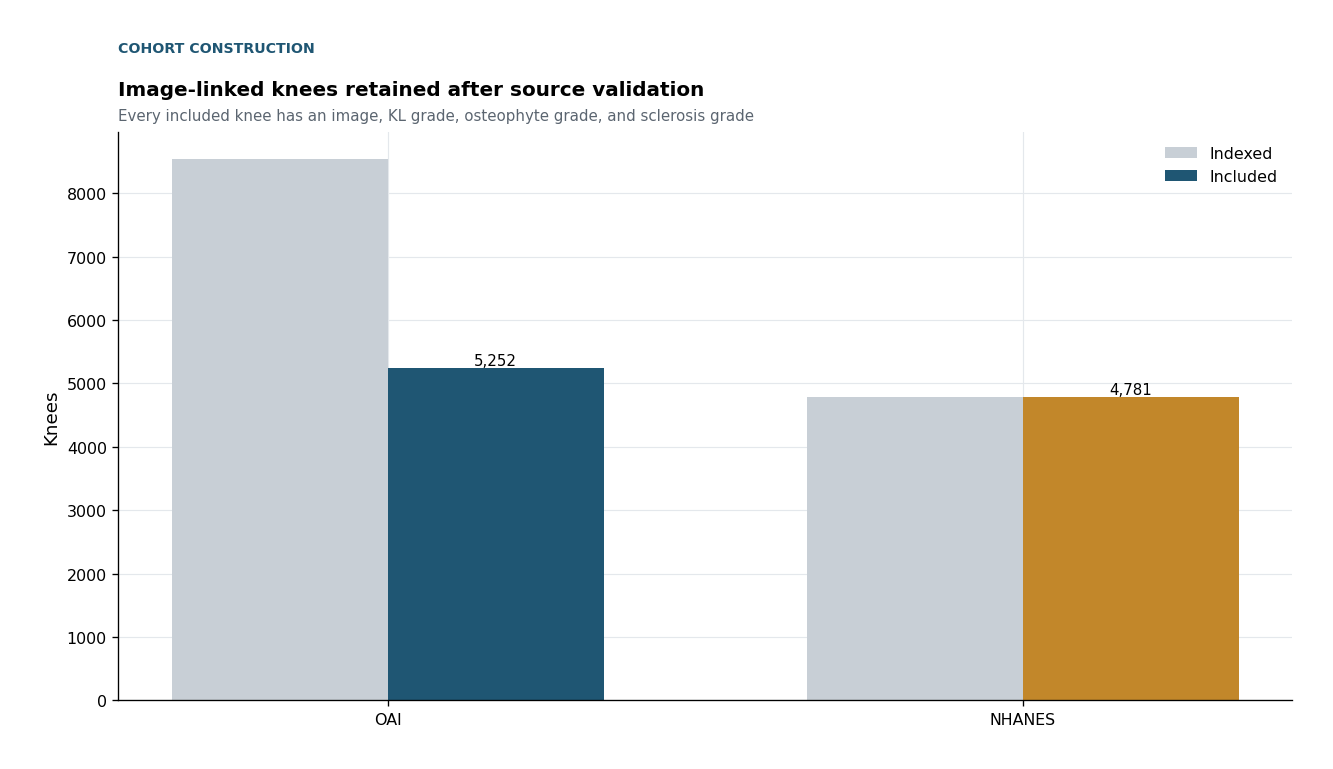

In [15]:



flow_plot = cohort_accounting.copy()



labels = [

    "Indexed knees",

    "Included knees",

]



x = np.arange(len(flow_plot))

width = 0.34



fig, ax = plt.subplots(

    figsize=(10.5, 5.8),

    constrained_layout=True,

)



ax.bar(

    x - width / 2,

    flow_plot["indexed_knees"],

    width,

    label="Indexed",

    color=HAIRLINE,

)

ax.bar(

    x + width / 2,

    flow_plot["included_knees"],

    width,

    label="Included",

    color=[

        OAI_COLOR,

        NHANES_COLOR,

    ],

)



ax.set_xticks(

    x,

    flow_plot["dataset"],

)

ax.set_ylabel("Knees")

ax.legend(loc="upper right")



for position, row in enumerate(

    flow_plot.itertuples(index=False)

):

    ax.text(

        position + width / 2,

        row.included_knees,

        f"{row.included_knees:,}",

        ha="center",

        va="bottom",

        fontsize=9,

    )



panel_title(

    ax,

    "Cohort construction",

    "Image-linked knees retained after source validation",

    "Every included knee has an image, KL grade, osteophyte grade, and sclerosis grade",

)



save_figure(

    fig,

    "N01_F01_cohort_flow",

)

/tmp/ipykernel_444/705813486.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  availability_numeric = availability.replace({


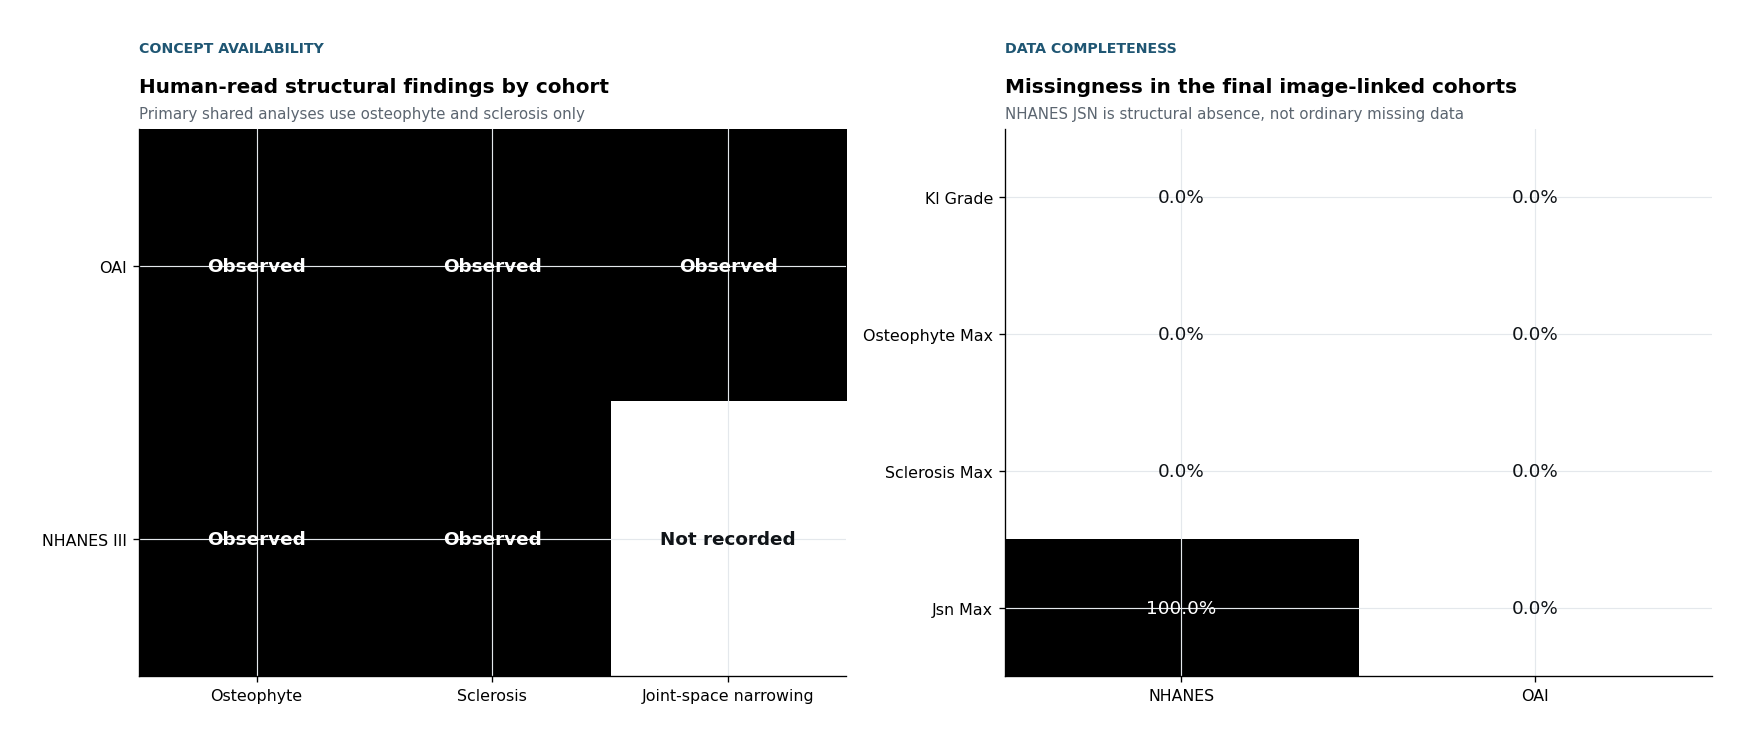

In [16]:



availability = pd.DataFrame(

    [

        ["Observed", "Observed", "Observed"],

        ["Observed", "Observed", "Not recorded"],

    ],

    index=["OAI", "NHANES III"],

    columns=[

        "Osteophyte",

        "Sclerosis",

        "Joint-space narrowing",

    ],

)



availability_numeric = availability.replace({

    "Observed": 1,

    "Not recorded": 0,

}).astype(float)



fig, axes = plt.subplots(

    1,

    2,

    figsize=(14.0, 5.6),

    constrained_layout=True,

)



ax = axes[0]

image = ax.imshow(

    availability_numeric.to_numpy(),

    cmap="Greys",

    vmin=0,

    vmax=1,

    aspect="auto",

)

ax.set_xticks(

    range(len(availability.columns)),

    [

        textwrap.fill(column, width=22)

        for column in availability.columns

    ],

)

ax.set_yticks(

    range(len(availability.index)),

    availability.index,

)



for row in range(availability.shape[0]):

    for column in range(availability.shape[1]):

        value = availability.iloc[row, column]

        ax.text(

            column,

            row,

            value,

            ha="center",

            va="center",

            color=PAPER if value == "Observed" else INK,

            fontweight="bold",

        )



panel_title(

    ax,

    "Concept availability",

    "Human-read structural findings by cohort",

    "Primary shared analyses use osteophyte and sclerosis only",

)



ax = axes[1]



missing_matrix = (

    missingness

    .pivot(

        index="variable",

        columns="dataset",

        values="missing_percent",

    )

    .reindex([

        "kl_grade",

        "osteophyte_max",

        "sclerosis_max",

        "jsn_max",

    ])

)



image = ax.imshow(

    missing_matrix.to_numpy(),

    cmap="Greys",

    vmin=0,

    vmax=100,

    aspect="auto",

)

ax.set_xticks(

    range(len(missing_matrix.columns)),

    missing_matrix.columns,

)

ax.set_yticks(

    range(len(missing_matrix.index)),

    [

        label.replace("_", " ").title()

        for label in missing_matrix.index

    ],

)



for row in range(missing_matrix.shape[0]):

    for column in range(missing_matrix.shape[1]):

        value = missing_matrix.iloc[row, column]

        ax.text(

            column,

            row,

            f"{value:.1f}%",

            ha="center",

            va="center",

            color=PAPER if value >= 55 else INK,

        )



panel_title(

    ax,

    "Data completeness",

    "Missingness in the final image-linked cohorts",

    "NHANES JSN is structural absence, not ordinary missing data",

)



save_figure(

    fig,

    "N01_F02_missingness_and_availability",

)

# 10. KL and shared-concept distributions

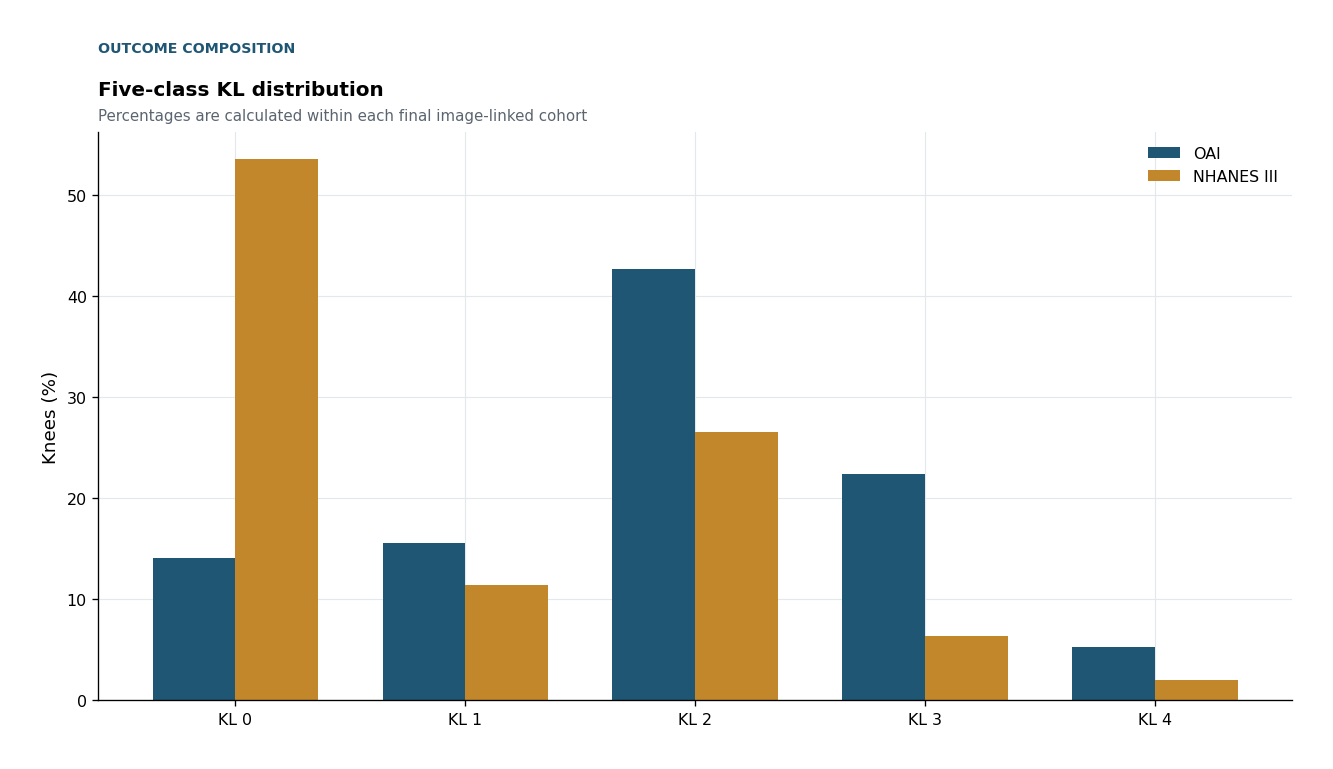

,dataset,kl_grade,knees,percent
0,OAI,0,740,14.089871
1,OAI,1,815,15.517898
2,OAI,2,2240,42.650419
3,OAI,3,1178,22.429551
4,OAI,4,279,5.312262
5,NHANES,0,2561,53.566200
6,NHANES,1,546,11.420205
7,NHANES,2,1271,26.584397
8,NHANES,3,306,6.400335
9,NHANES,4,97,2.028864


In [17]:



distribution_frames = {

    "OAI": OAI_INCLUDED,

    "NHANES": NHANES_INCLUDED,

}



kl_rows = []



for dataset, frame in distribution_frames.items():

    counts = (

        frame["kl_grade"]

        .value_counts()

        .reindex(KL_LEVELS, fill_value=0)

    )

    denominator = counts.sum()



    for grade, count in counts.items():

        kl_rows.append({

            "dataset": dataset,

            "kl_grade": int(grade),

            "knees": int(count),

            "percent": 100 * count / denominator,

        })



kl_distribution = pd.DataFrame(kl_rows)



atomic_csv(

    kl_distribution,

    TABLES / "N01_T03_kl_distribution.csv",

)



pivot = (

    kl_distribution

    .pivot(

        index="kl_grade",

        columns="dataset",

        values="percent",

    )

    .fillna(0)

)



x = np.arange(len(KL_LEVELS))

width = 0.36



fig, ax = plt.subplots(

    figsize=(10.5, 5.8),

    constrained_layout=True,

)



ax.bar(

    x - width / 2,

    pivot["OAI"],

    width,

    label="OAI",

    color=OAI_COLOR,

)

ax.bar(

    x + width / 2,

    pivot["NHANES"],

    width,

    label="NHANES III",

    color=NHANES_COLOR,

)



ax.set_xticks(

    x,

    [f"KL {grade}" for grade in KL_LEVELS],

)

ax.set_ylabel("Knees (%)")

ax.legend(loc="upper right")



panel_title(

    ax,

    "Outcome composition",

    "Five-class KL distribution",

    "Percentages are calculated within each final image-linked cohort",

)



save_figure(

    fig,

    "N01_F03_kl_distribution",

)



display(kl_distribution)

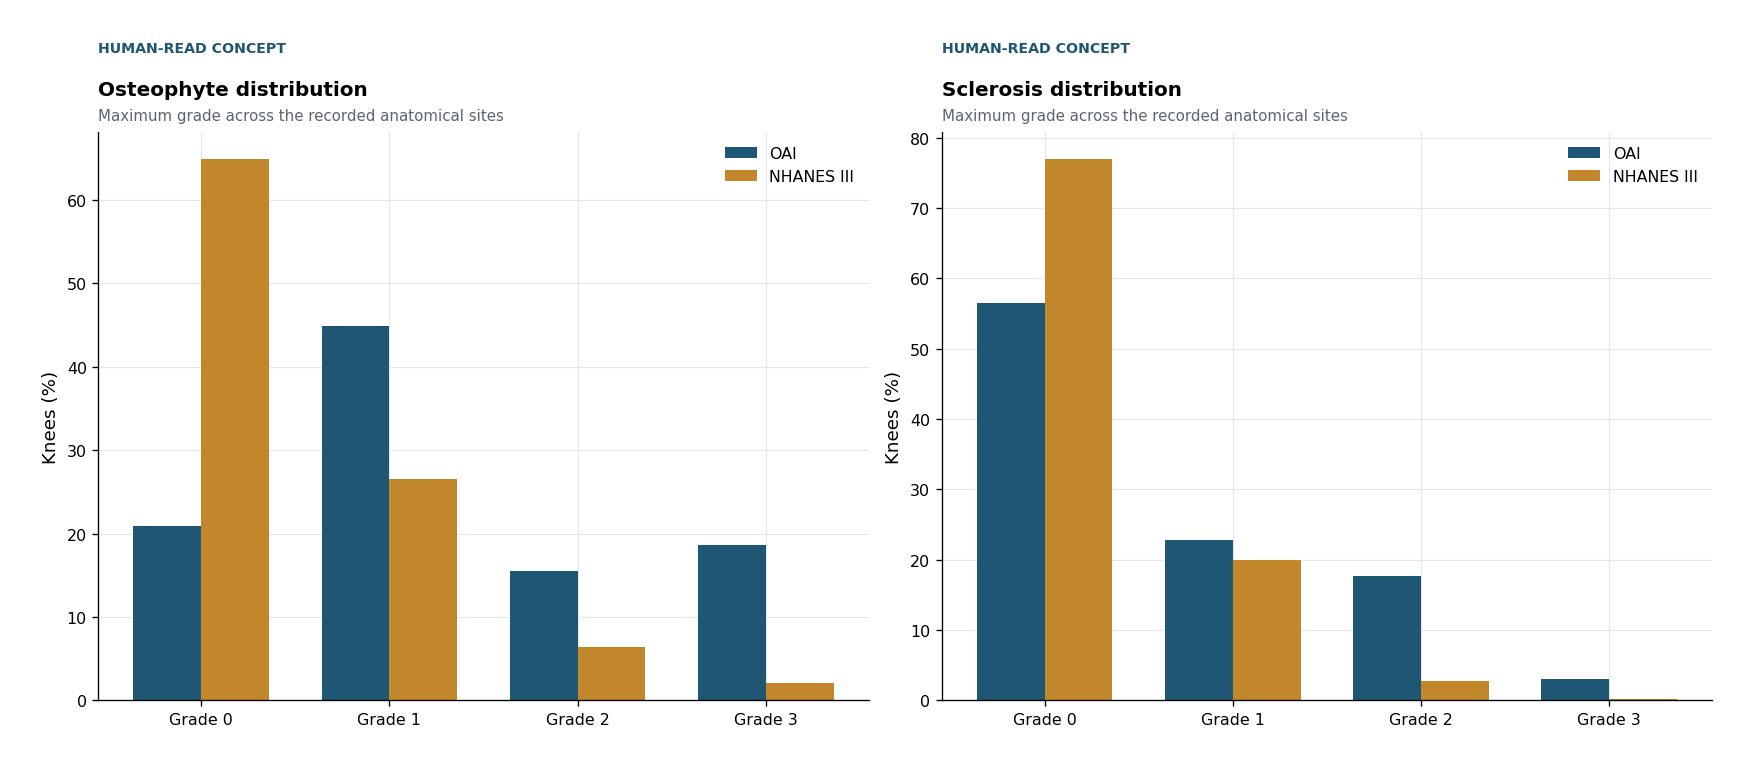

,concept,dataset,grade,knees,percent
0,osteophyte_max,OAI,0,1101,20.963442
1,osteophyte_max,OAI,1,2357,44.878142
2,osteophyte_max,OAI,2,814,15.498858
3,osteophyte_max,OAI,3,980,18.659558
4,osteophyte_max,NHANES,0,3105,64.944572
5,osteophyte_max,NHANES,1,1271,26.584397
6,osteophyte_max,NHANES,2,304,6.358502
7,osteophyte_max,NHANES,3,101,2.112529
8,sclerosis_max,OAI,0,2965,56.454684
9,sclerosis_max,OAI,1,1198,22.810358


In [18]:



concept_distribution_rows = []



for concept in SHARED_CONCEPTS:

    for dataset, frame in distribution_frames.items():

        counts = (

            frame[concept]

            .value_counts()

            .reindex(

                CONCEPT_LEVELS[concept],

                fill_value=0,

            )

        )

        denominator = counts.sum()



        for grade, count in counts.items():

            concept_distribution_rows.append({

                "concept": concept,

                "dataset": dataset,

                "grade": int(grade),

                "knees": int(count),

                "percent": 100 * count / denominator,

            })



concept_distribution = pd.DataFrame(

    concept_distribution_rows

)



atomic_csv(

    concept_distribution,

    TABLES / "N01_T04_concept_distribution.csv",

)



fig, axes = plt.subplots(

    1,

    2,

    figsize=(14.0, 5.8),

    constrained_layout=True,

)



for ax, concept in zip(

    axes,

    SHARED_CONCEPTS,

):

    subset = concept_distribution.loc[

        concept_distribution["concept"].eq(concept)

    ]

    pivot = (

        subset

        .pivot(

            index="grade",

            columns="dataset",

            values="percent",

        )

        .fillna(0)

    )



    x = np.arange(len(CONCEPT_LEVELS[concept]))

    width = 0.36



    ax.bar(

        x - width / 2,

        pivot["OAI"],

        width,

        label="OAI",

        color=OAI_COLOR,

    )

    ax.bar(

        x + width / 2,

        pivot["NHANES"],

        width,

        label="NHANES III",

        color=NHANES_COLOR,

    )



    ax.set_xticks(

        x,

        [f"Grade {grade}" for grade in CONCEPT_LEVELS[concept]],

    )

    ax.set_ylabel("Knees (%)")

    ax.legend(loc="upper right")



    display_name = (

        "Osteophyte"

        if concept == "osteophyte_max"

        else "Sclerosis"

    )



    panel_title(

        ax,

        "Human-read concept",

        f"{display_name} distribution",

        "Maximum grade across the recorded anatomical sites",

    )



save_figure(

    fig,

    "N01_F04_shared_concept_distributions",

)



display(concept_distribution)

# 11. Patient-bootstrap radiographic shift map

For every shared concept, N01 reports:

- normalized Wasserstein distance;
- Jensen–Shannon distance;
- Cramér’s \(V\);
- a descriptive chi-square p-value;
- a patient-bootstrap 95% interval for normalized Wasserstein distance.

The bootstrap preserves both knees from a sampled participant.

In [19]:



def cramer_v(

    source: pd.Series,

    target: pd.Series,

    levels: tuple[int, ...],

) -> tuple[float, float]:

    source_counts = (

        source.value_counts()

        .reindex(levels, fill_value=0)

    )

    target_counts = (

        target.value_counts()

        .reindex(levels, fill_value=0)

    )



    table = pd.DataFrame({

        "OAI": source_counts,

        "NHANES": target_counts,

    }).T



    chi2_value, p_value, _, _ = chi2_contingency(

        table,

        correction=False,

    )



    sample_size = table.to_numpy().sum()

    denominator = min(

        table.shape[0] - 1,

        table.shape[1] - 1,

    )



    value = (

        np.sqrt(

            (chi2_value / sample_size)

            / denominator

        )

        if denominator > 0

        else np.nan

    )



    return float(value), float(p_value)



def concept_shift_effect(

    source: pd.Series,

    target: pd.Series,

    levels: tuple[int, ...],

) -> dict[str, float]:

    source_values = source.dropna().astype(float)

    target_values = target.dropna().astype(float)



    if (

        len(source_values)

        < CONFIG.minimum_nonmissing_per_cohort

    ):

        raise RuntimeError(

            "Too few nonmissing OAI concept labels."

        )



    if (

        len(target_values)

        < CONFIG.minimum_nonmissing_per_cohort

    ):

        raise RuntimeError(

            "Too few nonmissing NHANES concept labels."

        )



    value_range = max(levels) - min(levels)



    normalized_wasserstein = (

        wasserstein_distance(

            source_values,

            target_values,

        )

        / value_range

    )



    source_counts = (

        source_values.value_counts()

        .reindex(levels, fill_value=0)

    )

    target_counts = (

        target_values.value_counts()

        .reindex(levels, fill_value=0)

    )



    source_probability = (

        source_counts.to_numpy(dtype=float)

        / source_counts.sum()

    )

    target_probability = (

        target_counts.to_numpy(dtype=float)

        / target_counts.sum()

    )



    js_distance = float(

        jensenshannon(

            source_probability,

            target_probability,

            base=2,

        )

    )



    cramer, p_value = cramer_v(

        source_values,

        target_values,

        levels,

    )



    return {

        "wasserstein_normalized": float(normalized_wasserstein),

        "jensen_shannon": js_distance,

        "cramer_v": cramer,

        "standardized_mean_difference": standardized_mean_difference(source_values, target_values),

        "p_value": p_value,

    }



def patient_groups(

    frame: pd.DataFrame,

) -> tuple[np.ndarray, dict[str, np.ndarray]]:

    groups = {

        str(patient_id): group.index.to_numpy()

        for patient_id, group in frame.groupby(

            "patient_id",

            sort=False,

        )

    }

    patient_ids = np.asarray(

        sorted(groups),

        dtype=object,

    )

    return patient_ids, groups



def resample_patients(

    frame: pd.DataFrame,

    rng: np.random.Generator,

) -> pd.DataFrame:

    patient_ids, groups = patient_groups(frame)

    sampled = rng.choice(

        patient_ids,

        size=len(patient_ids),

        replace=True,

    )



    row_indices = np.concatenate([

        groups[str(patient_id)]

        for patient_id in sampled

    ])



    return frame.loc[row_indices].copy()



shift_rows = []

rng = np.random.default_rng(CONFIG.split_seed)



for concept in SHARED_CONCEPTS:

    levels = CONCEPT_LEVELS[concept]



    point = concept_shift_effect(

        OAI_INCLUDED[concept],

        NHANES_INCLUDED[concept],

        levels,

    )



    bootstrap_values = []



    for replicate in range(BOOTSTRAP_REPLICATES):

        oai_bootstrap = resample_patients(

            OAI_INCLUDED,

            rng,

        )

        nhanes_bootstrap = resample_patients(

            NHANES_INCLUDED,

            rng,

        )



        bootstrap_values.append(

            concept_shift_effect(

                oai_bootstrap[concept],

                nhanes_bootstrap[concept],

                levels,

            )["wasserstein_normalized"]

        )



    low, high = np.quantile(

        bootstrap_values,

        [

            CONFIG.alpha / 2,

            1 - CONFIG.alpha / 2,

        ],

    )



    shift_rows.append({

        "concept": concept,

        "oai_nonmissing": int(

            OAI_INCLUDED[concept].notna().sum()

        ),

        "nhanes_nonmissing": int(

            NHANES_INCLUDED[concept].notna().sum()

        ),

        **point,

        "ci_low": float(low),

        "ci_high": float(high),

        "bootstrap_replicates": len(bootstrap_values),

    })



concept_shift = (

    pd.DataFrame(shift_rows)

    .sort_values(

        "wasserstein_normalized",

        ascending=False,

    )

)



atomic_csv(

    concept_shift,

    TABLES / "N01_T05_concept_shift.csv",

)



display(concept_shift.round(4))

,concept,oai_nonmissing,nhanes_nonmissing,wasserstein_normalized,jensen_shannon,cramer_v,standardized_mean_difference,p_value,ci_low,ci_high,bootstrap_replicates
0,osteophyte_max,5252,4781,0.2874,0.4136,0.4693,-0.9916,0.0,0.2736,0.3009,2000
1,sclerosis_max,5252,4781,0.1371,0.2580,0.2850,-0.5766,0.0,0.1267,0.1483,2000


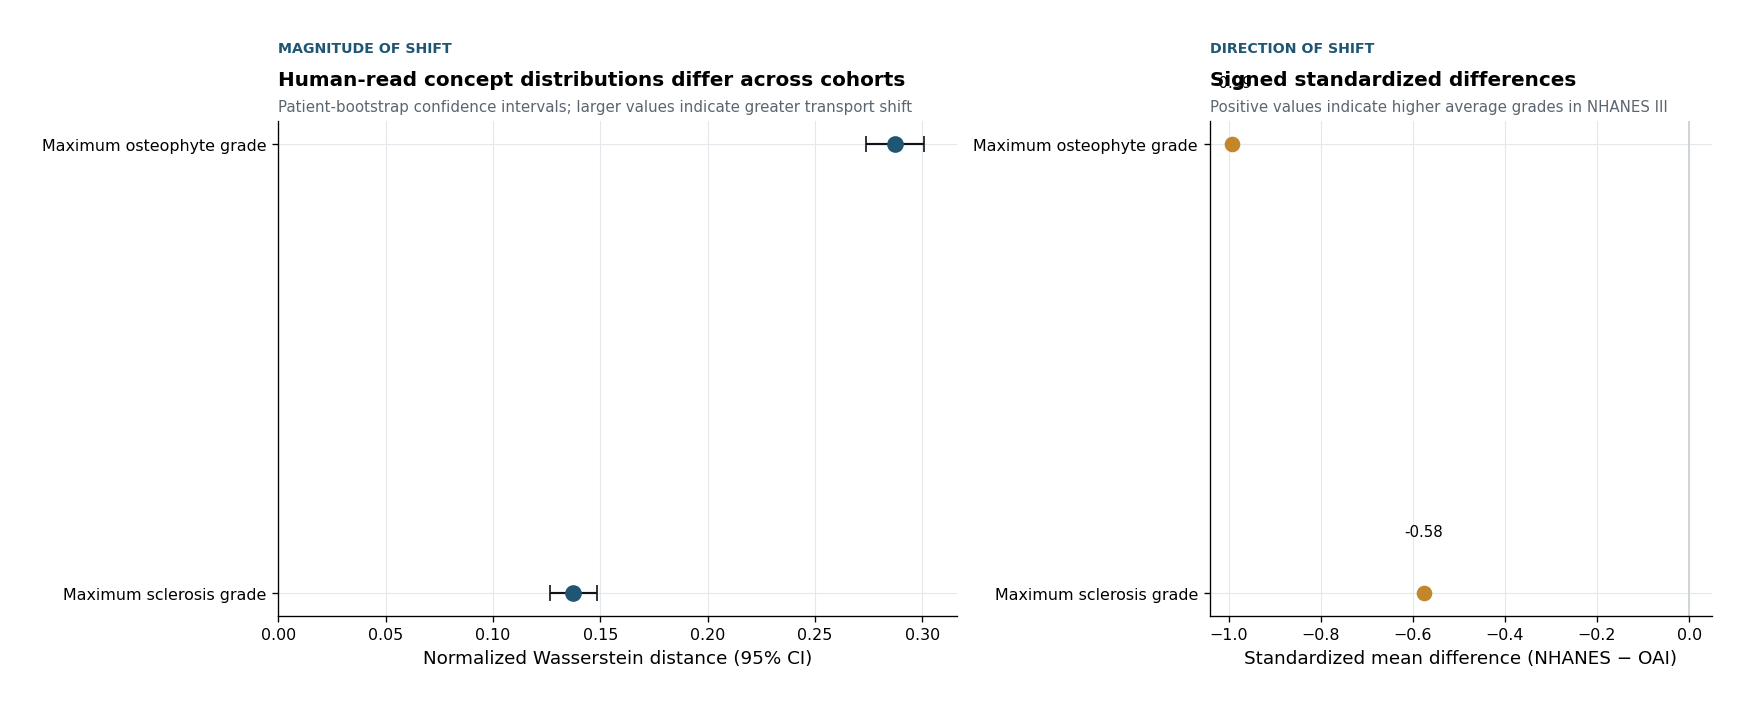

In [20]:



plot_data = concept_shift.sort_values("wasserstein_normalized").reset_index(drop=True)

y = np.arange(len(plot_data))

lower_error = plot_data["wasserstein_normalized"] - plot_data["ci_low"]

upper_error = plot_data["ci_high"] - plot_data["wasserstein_normalized"]

labels = {

    "osteophyte_max": "Maximum osteophyte grade",

    "sclerosis_max": "Maximum sclerosis grade",

}



fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.3), constrained_layout=True, gridspec_kw={"width_ratios": [1.35, 1]})

ax = axes[0]

ax.axvline(0, color=HAIRLINE, linewidth=1)

ax.errorbar(

    plot_data["wasserstein_normalized"], y,

    xerr=np.vstack([lower_error, upper_error]),

    fmt="o", color=OAI_COLOR, ecolor=INK, capsize=5, markersize=9, linewidth=1.3,

)

ax.set_yticks(y, [labels.get(value, value) for value in plot_data["concept"]])

ax.set_xlabel("Normalized Wasserstein distance (95% CI)")

ax.set_xlim(left=0)

panel_title(ax, "Magnitude of shift", "Human-read concept distributions differ across cohorts", "Patient-bootstrap confidence intervals; larger values indicate greater transport shift")



ax = axes[1]

ax.axvline(0, color=HAIRLINE, linewidth=1)

ax.scatter(plot_data["standardized_mean_difference"], y, s=70, color=NHANES_COLOR)

for row, value in enumerate(plot_data["standardized_mean_difference"]):

    ax.text(value, row + 0.12, f"{value:+.2f}", ha="center", va="bottom", fontsize=9)

ax.set_yticks(y, [labels.get(value, value) for value in plot_data["concept"]])

ax.set_xlabel("Standardized mean difference (NHANES − OAI)")

panel_title(ax, "Direction of shift", "Signed standardized differences", "Positive values indicate higher average grades in NHANES III")



save_figure(fig, "N01_F05_ranked_concept_shift")

# 12. Exact shared-concept support

The descriptive oracle state is:

\[
(	ext{maximum osteophyte grade},\ 	ext{maximum sclerosis grade})
\]

Support categories are frozen as:

- unsupported: zero OAI knees;
- rare: one to five OAI knees;
- supported: more than five OAI knees.

This is not the deployable probabilistic support score used later in N05.

In [21]:



def concept_state_label(row: pd.Series) -> str:

    return (

        f"Osteophyte={int(row['osteophyte_max'])}"

        f" | Sclerosis={int(row['sclerosis_max'])}"

    )



state_tables = {}



for dataset, frame in {

    "OAI": OAI_INCLUDED,

    "NHANES": NHANES_INCLUDED,

}.items():

    complete = frame.dropna(

        subset=list(SHARED_CONCEPTS)

    ).copy()



    grouped = (

        complete

        .groupby(

            list(SHARED_CONCEPTS)

        )

        .size()

        .rename("count")

        .reset_index()

    )



    grouped["state"] = grouped.apply(

        concept_state_label,

        axis=1,

    )

    grouped["prevalence"] = (

        grouped["count"] / len(complete)

    )



    state_tables[dataset] = grouped[

        ["state", "count", "prevalence"]

    ]



concept_states = (

    state_tables["OAI"]

    .rename(columns={

        "count": "oai_count",

        "prevalence": "oai_prevalence",

    })

    .merge(

        state_tables["NHANES"].rename(columns={

            "count": "nhanes_count",

            "prevalence": "nhanes_prevalence",

        }),

        on="state",

        how="outer",

    )

    .fillna(0)

)



concept_states["oai_count"] = (

    concept_states["oai_count"].astype(int)

)

concept_states["nhanes_count"] = (

    concept_states["nhanes_count"].astype(int)

)



concept_states["support_category"] = np.select(

    [

        concept_states["oai_count"].eq(0),

        concept_states["oai_count"].le(

            CONFIG.rare_source_count

        ),

    ],

    [

        "Unsupported",

        "Rare",

    ],

    default="Supported",

)



concept_states["target_to_source_ratio"] = (

    concept_states["nhanes_prevalence"]

    / concept_states["oai_prevalence"].replace(

        0,

        np.nan,

    )

)



concept_states = concept_states.sort_values(

    ["nhanes_count", "oai_count"],

    ascending=[False, True],

)



atomic_csv(

    concept_states,

    TABLES / "N01_T06_concept_state_support.csv",

)

atomic_csv(

    concept_states,

    RESULTS / "n01_concept_state_support.csv",

)



display(concept_states)

,state,oai_count,oai_prevalence,nhanes_count,nhanes_prevalence,support_category,target_to_source_ratio
0,Osteophyte=0 | Sclerosis=0,1098,0.209063,2905,0.607613,Supported,2.906362
3,Osteophyte=1 | Sclerosis=0,1464,0.278751,730,0.152688,Supported,0.547757
4,Osteophyte=1 | Sclerosis=1,688,0.130998,501,0.104790,Supported,0.799936
8,Osteophyte=2 | Sclerosis=1,286,0.054455,208,0.043506,Supported,0.798920
1,Osteophyte=0 | Sclerosis=1,2,0.000381,198,0.041414,Rare,108.752981
9,Osteophyte=2 | Sclerosis=2,255,0.048553,51,0.010667,Supported,0.219703
12,Osteophyte=3 | Sclerosis=1,222,0.042270,49,0.010249,Supported,0.242465
7,Osteophyte=2 | Sclerosis=0,253,0.048172,44,0.009203,Supported,0.191046
5,Osteophyte=1 | Sclerosis=2,204,0.038842,40,0.008366,Supported,0.215395
13,Osteophyte=3 | Sclerosis=2,471,0.089680,38,0.007948,Supported,0.088628


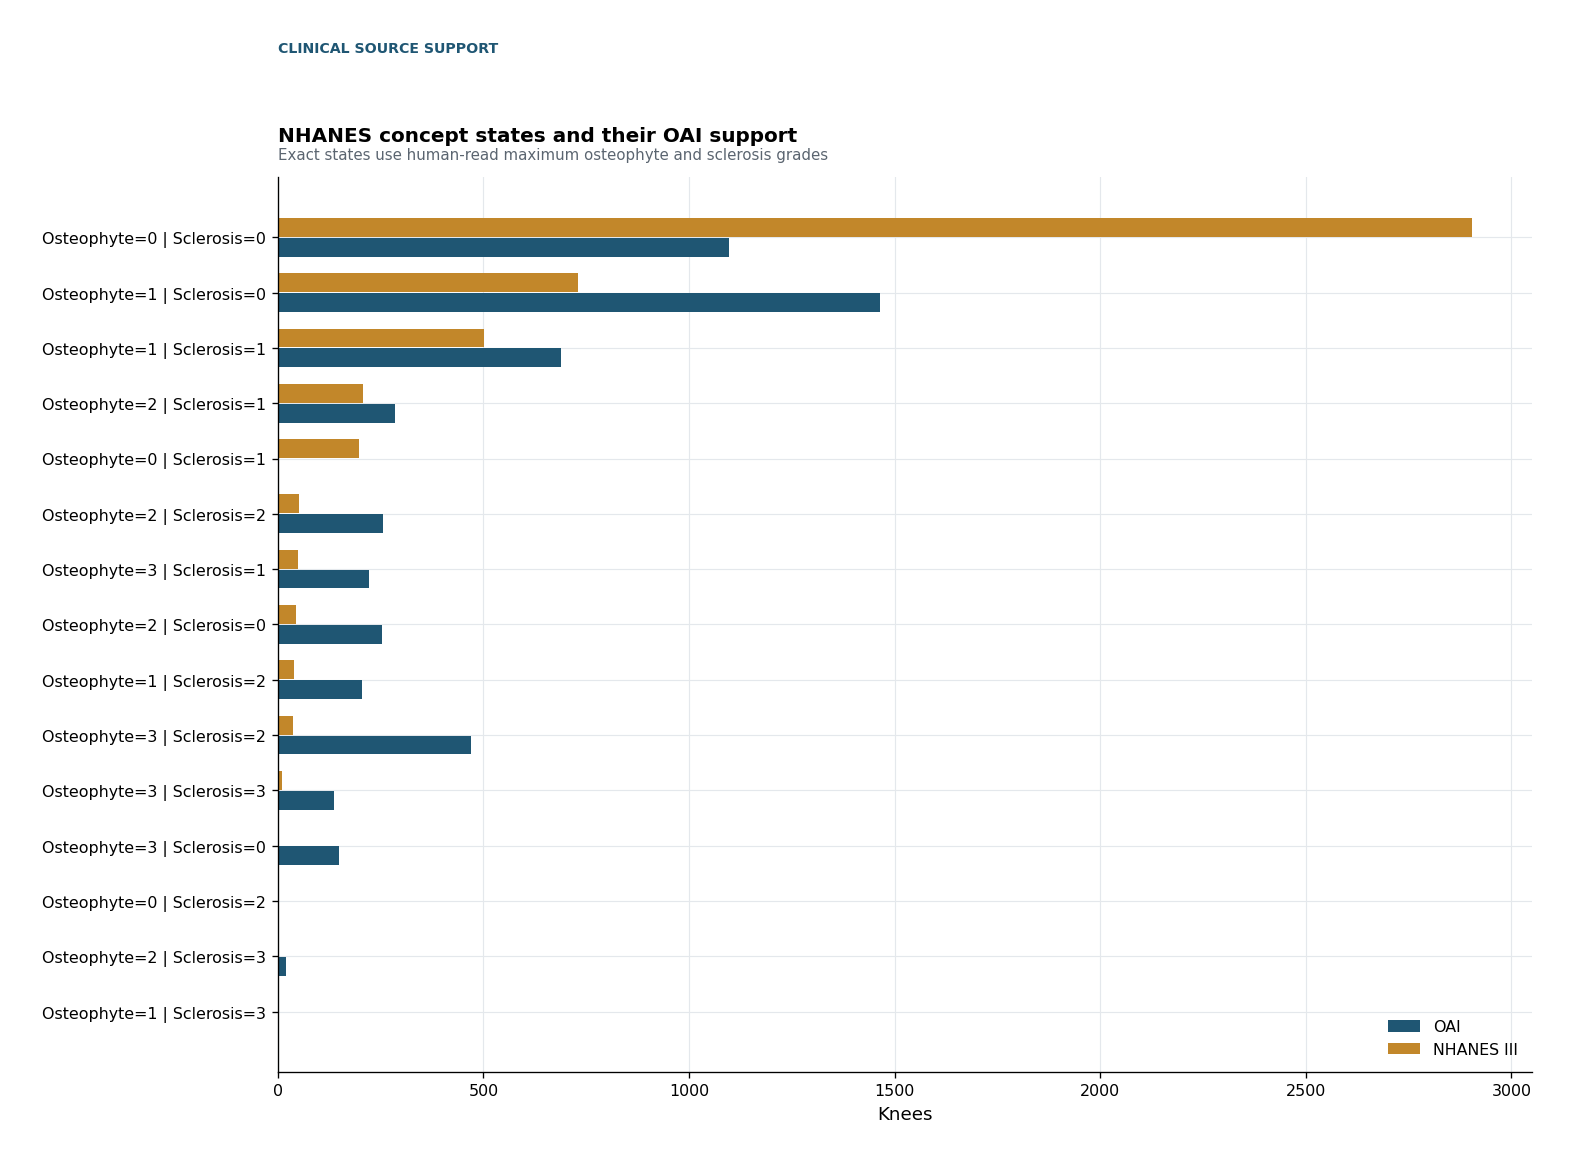

In [22]:



plot_states = (

    concept_states

    .head(CONFIG.maximum_plotted_states)

    .sort_values("nhanes_count")

)



y = np.arange(len(plot_states))



fig, ax = plt.subplots(

    figsize=(

        12.5,

        max(

            6.5,

            0.42 * len(plot_states) + 2.8,

        ),

    ),

    constrained_layout=True,

)



ax.barh(

    y - 0.18,

    plot_states["oai_count"],

    height=0.34,

    color=OAI_COLOR,

    label="OAI",

)

ax.barh(

    y + 0.18,

    plot_states["nhanes_count"],

    height=0.34,

    color=NHANES_COLOR,

    label="NHANES III",

)



ax.set_yticks(

    y,

    [

        textwrap.fill(state, width=45)

        for state in plot_states["state"]

    ],

)

ax.set_xlabel("Knees")

ax.legend(loc="lower right")



panel_title(

    ax,

    "Clinical source support",

    "NHANES concept states and their OAI support",

    "Exact states use human-read maximum osteophyte and sclerosis grades",

)



save_figure(

    fig,

    "N01_F06_concept_state_support",

)

# 13. Discovery–confirmation balance

This section verifies that the protected split preserves the broad KL and concept composition of NHANES.

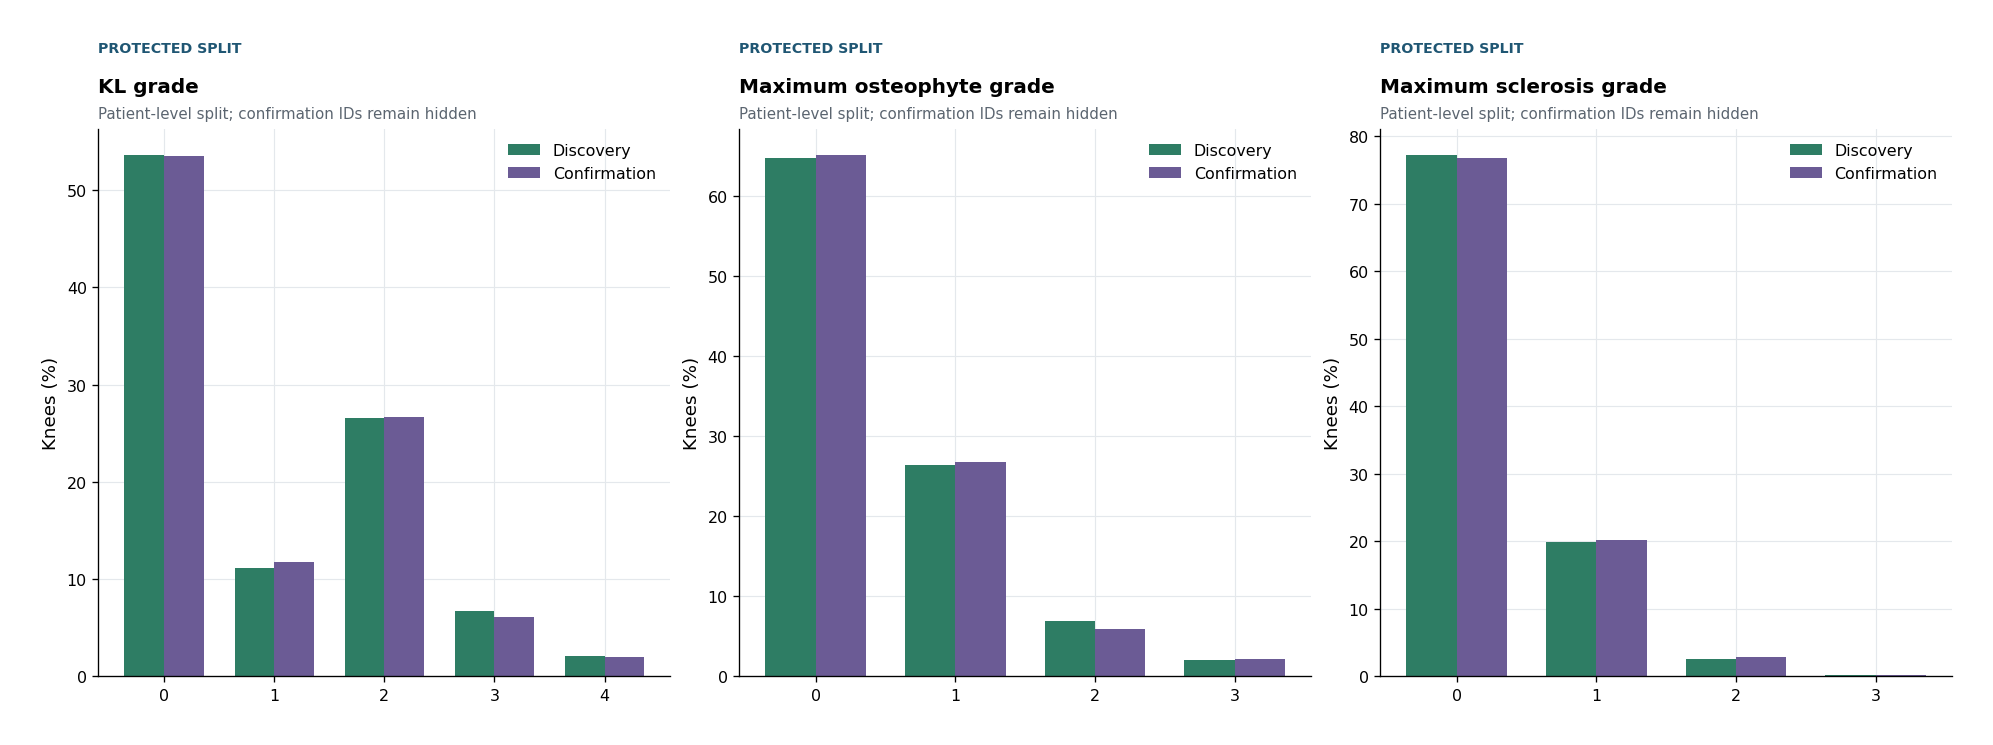

In [23]:



balance_variables = (

    "kl_grade",

    "osteophyte_max",

    "sclerosis_max",

)



balance_rows = []



for variable in balance_variables:

    levels = (

        KL_LEVELS

        if variable == "kl_grade"

        else CONCEPT_LEVELS[variable]

    )



    for subset_name, frame in {

        "Discovery": NHANES_DISCOVERY,

        "Confirmation": NHANES_CONFIRMATION,

    }.items():

        counts = (

            frame[variable]

            .value_counts()

            .reindex(levels, fill_value=0)

        )

        denominator = counts.sum()



        for level, count in counts.items():

            balance_rows.append({

                "variable": variable,

                "subset": subset_name,

                "level": int(level),

                "knees": int(count),

                "percent": 100 * count / denominator,

            })



split_balance = pd.DataFrame(balance_rows)



atomic_csv(

    split_balance,

    RESULTS / "n01_split_balance.csv",

)



fig, axes = plt.subplots(

    1,

    3,

    figsize=(16.0, 5.6),

    constrained_layout=True,

)



display_names = {

    "kl_grade": "KL grade",

    "osteophyte_max": "Maximum osteophyte grade",

    "sclerosis_max": "Maximum sclerosis grade",

}



for ax, variable in zip(

    axes,

    balance_variables,

):

    subset = split_balance.loc[

        split_balance["variable"].eq(variable)

    ]

    pivot = (

        subset

        .pivot(

            index="level",

            columns="subset",

            values="percent",

        )

        .fillna(0)

    )



    x = np.arange(len(pivot))

    width = 0.36



    ax.bar(

        x - width / 2,

        pivot["Discovery"],

        width,

        label="Discovery",

        color=DISCOVERY_COLOR,

    )

    ax.bar(

        x + width / 2,

        pivot["Confirmation"],

        width,

        label="Confirmation",

        color=CONFIRMATION_COLOR,

    )



    ax.set_xticks(

        x,

        [str(level) for level in pivot.index],

    )

    ax.set_ylabel("Knees (%)")

    ax.legend(loc="upper right")



    panel_title(

        ax,

        "Protected split",

        display_names[variable],

        "Patient-level split; confirmation IDs remain hidden",

    )



save_figure(

    fig,

    "N01_F07_discovery_confirmation_balance",

)

# 13.1. Figure metadata and captions

Captions, questions, and source tables are saved with the analysis artifacts.

In [24]:



figure_metadata = [

    {"stem": "N01_F01_cohort_flow", "question": "How many image-linked knees remain after validation?", "caption": "Image-linked knees retained after source validation in OAI and NHANES III.", "source": "N01_T01_cohort_accounting.csv"},

    {"stem": "N01_F02_missingness_and_availability", "question": "Which structural findings are observed in each cohort?", "caption": "Availability and missingness of human-read structural findings; NHANES III does not record JSN.", "source": "n01_missingness.csv"},

    {"stem": "N01_F03_kl_distribution", "question": "How does KL severity composition differ?", "caption": "Five-class KL distributions in the final image-linked cohorts.", "source": "N01_T03_kl_distribution.csv"},

    {"stem": "N01_F04_shared_concept_distributions", "question": "How do shared structural findings differ?", "caption": "Maximum human-read osteophyte and sclerosis grade distributions.", "source": "N01_T04_concept_distribution.csv"},

    {"stem": "N01_F05_ranked_concept_shift", "question": "Which shared concept shifts most strongly?", "caption": "Forest plot of normalized Wasserstein distances with patient-bootstrap intervals and signed standardized mean differences.", "source": "N01_T05_concept_shift.csv"},

    {"stem": "N01_F06_concept_state_support", "question": "Which NHANES concept states are rare or unsupported in OAI?", "caption": "Counts of exact osteophyte–sclerosis states in OAI and NHANES III.", "source": "N01_T06_concept_state_support.csv"},

    {"stem": "N01_F07_discovery_confirmation_balance", "question": "Did the protected split preserve NHANES composition?", "caption": "KL, osteophyte, and sclerosis composition in discovery and confirmation subsets.", "source": "n01_split_balance.csv"},

]

write_figure_metadata(figure_metadata)

display(pd.DataFrame(figure_metadata))

,stem,question,caption,source
0,N01_F01_cohort_flow,How many image-linked knees remain after valid...,Image-linked knees retained after source valid...,N01_T01_cohort_accounting.csv
1,N01_F02_missingness_and_availability,Which structural findings are observed in each...,Availability and missingness of human-read str...,n01_missingness.csv
2,N01_F03_kl_distribution,How does KL severity composition differ?,Five-class KL distributions in the final image...,N01_T03_kl_distribution.csv
3,N01_F04_shared_concept_distributions,How do shared structural findings differ?,Maximum human-read osteophyte and sclerosis gr...,N01_T04_concept_distribution.csv
4,N01_F05_ranked_concept_shift,Which shared concept shifts most strongly?,Forest plot of normalized Wasserstein distance...,N01_T05_concept_shift.csv
5,N01_F06_concept_state_support,Which NHANES concept states are rare or unsupp...,Counts of exact osteophyte–sclerosis states in...,N01_T06_concept_state_support.csv
6,N01_F07_discovery_confirmation_balance,Did the protected split preserve NHANES compos...,"KL, osteophyte, and sclerosis composition in d...",n01_split_balance.csv


# 14. Freeze schema and cohort manifests

The frozen schema records the raw inputs, parsing rules, concept definitions, cohort files, and split hashes required by N03–N05.

In [25]:



required_frozen_schema_objects = {

    "oai_feature_schema": oai_feature_schema,

    "NHANES_FIELD_NAMES": NHANES_FIELD_NAMES,

    "NHANES_FIELD_WIDTHS": NHANES_FIELD_WIDTHS,

    "OAI_INCLUDED": OAI_INCLUDED,

    "NHANES_INCLUDED": NHANES_INCLUDED,

}



for object_name, object_value in required_frozen_schema_objects.items():

    if object_value is None:

        raise RuntimeError(

            f"Required object is unavailable before schema freezing: {object_name}"

        )



oai_family_sources = {

    str(row.family): [

        value.strip()

        for value in str(row.source_columns).split("|")

        if value.strip()

    ]

    for row in oai_feature_schema.itertuples(index=False)

}



required_oai_families = {

    "kl",

    "osteophyte",

    "jsn",

    "sclerosis",

}



missing_oai_families = (

    required_oai_families

    - set(oai_family_sources)

)



if missing_oai_families:

    raise RuntimeError(

        "The exported OAI parser schema is incomplete. Missing families: "

        + ", ".join(sorted(missing_oai_families))

    )



frozen_schema = {

    "created_utc": datetime.now(timezone.utc).isoformat(),

    "stage": STAGE,

    "run_mode": RUN_MODE,

    "raw_inputs": {

        "oai_assessment": {

            "path": str(OAI_ASSESSMENT),

            "sha256": sha256_file(OAI_ASSESSMENT),

        },

        "oai_image_index": {

            "path": str(OAI_IMAGE_INDEX),

            "sha256": sha256_file(OAI_IMAGE_INDEX),

        },

        "nhanes_xr": {

            "path": str(NHANES_XR),

            "sha256": sha256_file(NHANES_XR),

        },

        "nhanes_label_index": {

            "path": str(NHANES_LABEL_INDEX),

            "sha256": sha256_file(NHANES_LABEL_INDEX),

        },

    },

    "oai_parsing": {

        "read_project": 15,

        "duplicate_resolution": (

            "Median across duplicate patient-side readings"

        ),

        "families": {

            family: oai_family_sources[family]

            for family in (

                "kl",

                "osteophyte",

                "jsn",

                "sclerosis",

            )

        },

        "schema_table": str(

            RESULTS / "n01_oai_feature_schema.csv"

        ),

    },

    "nhanes_parsing": {

        "field_names": NHANES_FIELD_NAMES,

        "field_widths": NHANES_FIELD_WIDTHS,

        "osteophyte_sites_per_knee": 4,

        "sclerosis_sites_per_knee": 4,

        "jsn_policy": (

            "Structurally missing; never zero-imputed"

        ),

    },

    "shared_concepts": list(SHARED_CONCEPTS),

    "shared_concept_levels": {

        concept: list(CONCEPT_LEVELS[concept])

        for concept in SHARED_CONCEPTS

    },

    "primary_outcome": {

        "name": "kl_grade",

        "levels": list(KL_LEVELS),

    },

    "cohort_outputs": {

        "oai": str(

            RESULTS / "n01_oai_cohort.csv"

        ),

        "nhanes": str(

            RESULTS / "n01_nhanes_cohort_with_split.csv"

        ),

    },

    "nhanes_split": {

        "discovery_manifest": str(

            DISCOVERY_MANIFEST

        ),

        "confirmation_manifest": str(

            CONFIRMATION_MANIFEST

        ),

        "metadata": str(SPLIT_METADATA),

        "confirmation_manifest_sha256": sha256_file(

            CONFIRMATION_MANIFEST

        ),

    },

    "prior_nhanes_exploration_disclosed": True,

}



FROZEN_SCHEMA_PATH = (

    MANIFESTS / "n01_frozen_schema.json"

)



atomic_json(

    frozen_schema,

    FROZEN_SCHEMA_PATH,

)



cohort_manifest = pd.DataFrame([

    {

        "dataset": "OAI",

        "path": str(

            RESULTS / "n01_oai_cohort.csv"

        ),

        "sha256": sha256_file(

            RESULTS / "n01_oai_cohort.csv"

        ),

        "knees": len(OAI_INCLUDED),

        "patients": OAI_INCLUDED["patient_id"].nunique(),

    },

    {

        "dataset": "NHANES",

        "path": str(

            RESULTS / "n01_nhanes_cohort_with_split.csv"

        ),

        "sha256": sha256_file(

            RESULTS / "n01_nhanes_cohort_with_split.csv"

        ),

        "knees": len(NHANES_INCLUDED),

        "patients": NHANES_INCLUDED["patient_id"].nunique(),

    },

])



atomic_csv(

    cohort_manifest,

    MANIFESTS / "n01_cohort_manifest.csv",

)



display(cohort_manifest)

,dataset,path,sha256,knees,patients
0,OAI,/content/drive/MyDrive/Master Thesis/thesis/re...,1e6c51b732ad8d78d2e49f0978e8b0d2d6325fc57ba2b5...,5252,2647
1,NHANES,/content/drive/MyDrive/Master Thesis/thesis/re...,fdc1356839b08c93c4f4f4f919335f0f3aef224914a5ac...,4781,2410


# 15. Acceptance certificate

N01 passes because the data construction is valid and complete.

It does not require a particular shift direction or magnitude.

In [26]:



required_results = [

    "environment.json",

    "n01_source_registry.csv",

    "n01_oai_feature_schema.csv",

    "n01_nhanes_fixed_width_layout.csv",

    "n01_oai_all_linked.csv",

    "n01_oai_cohort.csv",

    "n01_nhanes_all_linked.csv",

    "n01_nhanes_cohort.csv",

    "n01_nhanes_cohort_with_split.csv",

    "n01_exclusion_flow.csv",

    "n01_missingness.csv",

    "n01_concept_availability.csv",

    "n01_concept_state_support.csv",

    "n01_split_balance.csv",

    "figure_metadata.json",

]



required_tables = [

    "N01_T00_descriptive_statistics.csv",

    "N01_T01_cohort_accounting.csv",

    "N01_T02_nhanes_split.csv",

    "N01_T03_kl_distribution.csv",

    "N01_T04_concept_distribution.csv",

    "N01_T05_concept_shift.csv",

    "N01_T06_concept_state_support.csv",

]



required_figure_stems = [

    "N01_F01_cohort_flow",

    "N01_F02_missingness_and_availability",

    "N01_F03_kl_distribution",

    "N01_F04_shared_concept_distributions",

    "N01_F05_ranked_concept_shift",

    "N01_F06_concept_state_support",

    "N01_F07_discovery_confirmation_balance",

]



required_figures = [

    f"{stem}.{extension}"

    for stem in required_figure_stems

    for extension in ("pdf", "png")

]



required_manifests = [

    "shared_concept_registry.csv",

    "nhanes_discovery_patients.csv",

    "nhanes_confirmation_patients.csv",

    "nhanes_split_metadata.json",

    "n01_frozen_schema.json",

    "n01_cohort_manifest.csv",

]



criteria = {

    "N00 accepted":

        n00_status.get("accepted") is True,

    "all original source files exist":

        all(path.exists() for path in required_sources),

    "no forbidden derived file was used":

        not source_registry["forbidden_derived_input"].any(),

    "OAI included knee keys are unique":

        OAI_INCLUDED["knee_key"].is_unique,

    "NHANES included knee keys are unique":

        NHANES_INCLUDED["knee_key"].is_unique,

    "OAI KL labels agree with image index":

        bool(OAI_INCLUDED["kl_agreement"].all()),

    "NHANES KL labels agree with image index":

        bool(NHANES_INCLUDED["kl_agreement"].all()),

    "all included OAI images exist":

        bool(OAI_INCLUDED["image_exists"].all()),

    "all included NHANES images exist":

        bool(NHANES_INCLUDED["image_exists"].all()),

    "shared concepts are human-read in both cohorts":

        all(

            OAI_INCLUDED[concept].notna().any()

            and NHANES_INCLUDED[concept].notna().any()

            for concept in SHARED_CONCEPTS

        ),

    "NHANES JSN is structurally missing":

        bool(NHANES_INCLUDED["jsn_max"].isna().all()),

    "NHANES split is patient-disjoint":

        not bool(discovery_set & confirmation_set),

    "NHANES split covers every included patient":

        discovery_set | confirmation_set

        == all_nhanes_patients,

    "extended integrity checks passed":

        bool(sanity_checks["passed"].all()),

    "all patients contribute one or two knees":

        all(frame.groupby("patient_id")["side"].nunique().between(1, 2).all() for frame in (OAI_INCLUDED, NHANES_INCLUDED)),

    "paper mode completed":

        RUN_MODE == "paper",

}



passed = all(criteria.values())



status = {

    "stage": STAGE,

    "run_mode": RUN_MODE,

    "passed": passed,

    "criteria": criteria,

    "cohorts": {

        "OAI": {

            "knees": len(OAI_INCLUDED),

            "patients": int(

                OAI_INCLUDED["patient_id"].nunique()

            ),

        },

        "NHANES": {

            "knees": len(NHANES_INCLUDED),

            "patients": int(

                NHANES_INCLUDED["patient_id"].nunique()

            ),

        },

        "NHANES_discovery": {

            "knees": len(NHANES_DISCOVERY),

            "patients": int(

                NHANES_DISCOVERY["patient_id"].nunique()

            ),

        },

        "NHANES_confirmation": {

            "knees": len(NHANES_CONFIRMATION),

            "patients": int(

                NHANES_CONFIRMATION["patient_id"].nunique()

            ),

        },

    },

    "shared_concepts": list(SHARED_CONCEPTS),

    "nhanes_jsn_policy": (

        "Structurally missing; never zero-imputed"

    ),

    "concept_shift": concept_shift.to_dict(

        orient="records"

    ),

    "unsupported_states": int(

        concept_states["support_category"]

        .eq("Unsupported")

        .sum()

    ),

    "rare_states": int(

        concept_states["support_category"]

        .eq("Rare")

        .sum()

    ),

    "confirmation_manifest_sha256": sha256_file(

        CONFIRMATION_MANIFEST

    ),

    "frozen_schema_sha256": sha256_file(

        FROZEN_SCHEMA_PATH

    ),

    "prior_nhanes_exploration_disclosed": True,

}



STATUS_PATH = RESULTS / "n01_status.json"



atomic_json(

    status,

    STATUS_PATH,

)



criteria_frame = pd.DataFrame({

    "criterion": list(criteria.keys()),

    "pass": list(criteria.values()),

})



atomic_csv(

    criteria_frame,

    RESULTS / "n01_acceptance_criteria.csv",

)



certificate_lines = [

    "=" * 76,

    "N01 DATA RECONSTRUCTION AND COHORT VALIDATION CERTIFICATE",

    "=" * 76,

    f"Run mode: {RUN_MODE}",

    f"Notebook passed: {'YES' if passed else 'NO'}",

    "",

]



for criterion, result in criteria.items():

    label = textwrap.shorten(

        criterion,

        width=58,

        placeholder="…",

    )

    certificate_lines.append(

        f"{label:<60} {'PASS' if result else 'FAIL'}"

    )



certificate_lines.extend([

    "",

    f"OAI included knees: {len(OAI_INCLUDED):,}",

    f"OAI included patients: {OAI_INCLUDED['patient_id'].nunique():,}",

    f"NHANES included knees: {len(NHANES_INCLUDED):,}",

    f"NHANES included patients: {NHANES_INCLUDED['patient_id'].nunique():,}",

    f"Shared concepts: {', '.join(SHARED_CONCEPTS)}",

    "NHANES JSN in primary analysis: NO",

    f"Confirmation manifest SHA-256: {sha256_file(CONFIRMATION_MANIFEST)}",

    "",

    f"READY FOR N02 AND N03: {'YES' if passed else 'NO'}",

    "=" * 76,

])



certificate = "\n".join(certificate_lines)



print(certificate)



(

    RESULTS / "n01_validation_certificate.txt"

).write_text(

    certificate,

    encoding="utf-8",

)



display(criteria_frame)



if not passed:

    raise RuntimeError(

        "N01 did not pass. Repair only the failed validation criteria."

    )

N01 DATA RECONSTRUCTION AND COHORT VALIDATION CERTIFICATE
Run mode: paper
Notebook passed: YES

N00 accepted                                                 PASS
all original source files exist                              PASS
no forbidden derived file was used                           PASS
OAI included knee keys are unique                            PASS
NHANES included knee keys are unique                         PASS
OAI KL labels agree with image index                         PASS
NHANES KL labels agree with image index                      PASS
all included OAI images exist                                PASS
all included NHANES images exist                             PASS
shared concepts are human-read in both cohorts               PASS
NHANES JSN is structurally missing                           PASS
NHANES split is patient-disjoint                             PASS
NHANES split covers every included patient                   PASS
extended integrity checks passed              

,criterion,pass
0,N00 accepted,True
1,all original source files exist,True
2,no forbidden derived file was used,True
3,OAI included knee keys are unique,True
4,NHANES included knee keys are unique,True
5,OAI KL labels agree with image index,True
6,NHANES KL labels agree with image index,True
7,all included OAI images exist,True
8,all included NHANES images exist,True
9,shared concepts are human-read in both cohorts,True


# 16. Required thesis disclosure

> NHANES III had been examined during earlier exploratory work. Observations that motivated the final hypotheses included external performance loss, grade-specific failure, and sparse source support for some concept states. To limit further adaptation, NHANES participants were divided into discovery and confirmation subsets before confirmatory reliability analysis. Prior exploratory access is disclosed, and the confirmation patient manifest was frozen before model-score evaluation.

# 17. Strict Google Drive save audit

The notebook is not complete merely because calculations ran.

The final audit verifies every required:

- result;
- table;
- PDF figure;
- PNG figure;
- shared manifest.

Missing artifacts produce a hard failure.

In [28]:



expected_results = required_results + [

    "n01_acceptance_criteria.csv",

    "n01_status.json",

    "n01_validation_certificate.txt",

    "figure_metadata.json",

]

expected_tables = required_tables

expected_figures = required_figures

expected_manifests = required_manifests

expected_checks = ["n01_integrity_checks.csv"]

expected_intermediate = [

    "oai_human_features_reconstructed.csv",

    "nhanes_human_features_reconstructed.csv",

]

expected_final = [

    "oai_cohort_frozen.csv",

    "nhanes_cohort_frozen.csv",

]



audit_rows = []

for category, folder, filenames in (

    ("result", RESULTS, expected_results),

    ("table", TABLES, expected_tables),

    ("figure", FIGURES, expected_figures),

    ("manifest", MANIFESTS, expected_manifests),

    ("check", CHECKS, expected_checks),

    ("intermediate", INTERMEDIATE, expected_intermediate),

    ("final", FINAL, expected_final),

):

    for filename in filenames:

        path = folder / filename

        audit_rows.append({

            "category": category,

            "file": filename,

            "exists": path.exists(),

            "size_bytes": path.stat().st_size if path.exists() else None,

            "sha256": sha256_file(path) if path.exists() else None,

            "path": str(path),

        })



drive_audit = pd.DataFrame(audit_rows)

atomic_csv(drive_audit, RESULTS / "n01_drive_save_audit.csv")

all_artifacts_present = bool(drive_audit["exists"].all())



drive_summary = {

    "stage": STAGE,

    "all_required_artifacts_present": all_artifacts_present,

    "missing_artifacts": drive_audit.loc[~drive_audit["exists"], "path"].tolist(),

    "results_directory": str(RESULTS),

    "figures_directory": str(FIGURES),

    "tables_directory": str(TABLES),

    "manifests_directory": str(MANIFESTS),

    "checks_directory": str(CHECKS),

    "intermediate_directory": str(INTERMEDIATE),

    "final_directory": str(FINAL),

    "audit_csv": str(RESULTS / "n01_drive_save_audit.csv"),

}

atomic_json(drive_summary, RESULTS / "n01_drive_save_summary.json")



status_after_audit = json.loads(STATUS_PATH.read_text(encoding="utf-8"))

status_after_audit["drive_save_audit_passed"] = all_artifacts_present

status_after_audit["passed"] = bool(status_after_audit.get("passed", False) and all_artifacts_present)

status_after_audit["drive_save_summary"] = str(RESULTS / "n01_drive_save_summary.json")

atomic_json(status_after_audit, STATUS_PATH)



build_report = {

    "question_answered": True,

    "datasets_reconstructed": True,

    "shared_concepts_frozen": True,

    "nhanes_confirmation_protected": True,

    "integrity_checks_passed": bool(sanity_checks["passed"].all()),

    "drive_save_audit_passed": all_artifacts_present,

    "ready_for_n02_and_n03": bool(status_after_audit["passed"]),

    "oai_knees": len(OAI_INCLUDED),

    "oai_patients": int(OAI_INCLUDED["patient_id"].nunique()),

    "nhanes_knees": len(NHANES_INCLUDED),

    "nhanes_patients": int(NHANES_INCLUDED["patient_id"].nunique()),

    "figures": len(expected_figures),

    "tables": len(expected_tables),

    "results": len(expected_results),

    "manifests": len(expected_manifests),

    "checks": len(expected_checks),

}

atomic_json(build_report, RESULTS / "n01_build_report.json")



manifest_rows = []

for folder in (RESULTS, FIGURES, TABLES, MANIFESTS, CHECKS, INTERMEDIATE, FINAL):

    for path in sorted(folder.glob("*")):

        if path.is_file() and path.name != "n01_output_manifest.csv":

            manifest_rows.append({

                "path": str(path.relative_to(PROJECT_ROOT)),

                "bytes": path.stat().st_size,

                "sha256": sha256_file(path),

                "modified_utc": datetime.fromtimestamp(path.stat().st_mtime, tz=timezone.utc).isoformat(),

                "generator": "N01_Data_Reconstruction_Cohorts_Shift.ipynb",

            })

output_manifest = pd.DataFrame(manifest_rows)

atomic_csv(output_manifest, RESULTS / "n01_output_manifest.csv")



display(drive_audit)



print()

print("=" * 76)

print("N01 COMPLETE BUILD REPORT")

print("=" * 76)

for key, value in build_report.items():

    print(f"{key.replace('_', ' ').title():<38} {value}")

print("=" * 76)

print("N01 GOOGLE DRIVE SAVE AUDIT")

print("=" * 76)

print("Results:", RESULTS)

print("Figures:", FIGURES)

print("Tables:", TABLES)

print("Manifests:", MANIFESTS)

print("Checks:", CHECKS)

print("Intermediate:", INTERMEDIATE)

print("Final cohorts:", FINAL)

print("Required analysis artifacts present:", all_artifacts_present)



if not all_artifacts_present:

    print("\nMissing artifacts:")

    for missing_path in drive_summary["missing_artifacts"]:

        print(" -", missing_path)

    raise RuntimeError("N01 save audit failed. Required artifacts are missing from Google Drive.")



print("\nALL REQUIRED N01 RESULTS, FIGURES, TABLES, CHECKS, COHORTS, AND MANIFESTS ARE PRESENT ON GOOGLE DRIVE.")

print("Final N01 status passed:", status_after_audit["passed"])

print("=" * 76)


,category,file,exists,size_bytes,sha256,path
0,result,environment.json,True,762,d1396b15e0de6c2eb063414dab6a5603968f8eb0726f1d...,/content/drive/MyDrive/Master Thesis/thesis/re...
1,result,n01_source_registry.csv,True,1139,137722eaf508a5665f2ef4379e71515778f628aec79ae5...,/content/drive/MyDrive/Master Thesis/thesis/re...
2,result,n01_oai_feature_schema.csv,True,386,f3130d1f7e66c8a61ac254999fffa9dcb1f599fdb9229b...,/content/drive/MyDrive/Master Thesis/thesis/re...
3,result,n01_nhanes_fixed_width_layout.csv,True,411,95d882dec02207c02f56aef7cb78506f5c60c64b3f3a1e...,/content/drive/MyDrive/Master Thesis/thesis/re...
4,result,n01_oai_all_linked.csv,True,1443659,8de466ca26d45c62825827b55822b256172e8d325f2e38...,/content/drive/MyDrive/Master Thesis/thesis/re...
5,result,n01_oai_cohort.csv,True,927784,1e6c51b732ad8d78d2e49f0978e8b0d2d6325fc57ba2b5...,/content/drive/MyDrive/Master Thesis/thesis/re...
6,result,n01_nhanes_all_linked.csv,True,848411,5d5798daf1e5b73dc71ba6556bd65ef16f31b983c5a185...,/content/drive/MyDrive/Master Thesis/thesis/re...
7,result,n01_nhanes_cohort.csv,True,846557,501c6fa560e2633e386ce08dabdf8aea4d935a07355cd3...,/content/drive/MyDrive/Master Thesis/thesis/re...
8,result,n01_nhanes_cohort_with_split.csv,True,901559,fdc1356839b08c93c4f4f4f919335f0f3aef224914a5ac...,/content/drive/MyDrive/Master Thesis/thesis/re...
9,result,n01_exclusion_flow.csv,True,319,1aae5f01a96aa9e5bcab22d85e35b2932fb774ba66c4a0...,/content/drive/MyDrive/Master Thesis/thesis/re...



N01 COMPLETE BUILD REPORT
Question Answered                      True
Datasets Reconstructed                 True
Shared Concepts Frozen                 True
Nhanes Confirmation Protected          True
Integrity Checks Passed                True
Drive Save Audit Passed                True
Ready For N02 And N03                  True
Oai Knees                              5252
Oai Patients                           2647
Nhanes Knees                           4781
Nhanes Patients                        2410
Figures                                14
Tables                                 7
Results                                19
Manifests                              6
Checks                                 1
N01 GOOGLE DRIVE SAVE AUDIT
Results: /content/drive/MyDrive/Master Thesis/thesis/results/N01
Figures: /content/drive/MyDrive/Master Thesis/thesis/figures/N01
Tables: /content/drive/MyDrive/Master Thesis/thesis/tables/N01
Manifests: /content/drive/MyDrive/Master Thesis/thesis/manife